# editing plots

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/ens.py -e RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 -v W --plotmean

In [1]:
from optparse import OptionParser
import sys
import os
import numpy as np
import datetime as DT 
import netCDF4 as ncdf
import glob
import pylab as P
from datetime import datetime
from src.plot_src.cbook2 import nice_mxmnintvl, nice_clevels
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy import ndimage
import re

import colormaps as cmaps

import json
import xarray as xr
import datetime as dt
import pandas as pd


from matplotlib.colors import LinearSegmentedColormap, to_rgb

_bin_delta = 1
radar_hgt = 0

_prior_files = "Prior_*"
_plotfilename = "DBZ_ConsistencyRatio"

sec_utime = "seconds since 1970-01-01 00:00:00"


## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})



num2obs = {11: ["VR"], 12:["DBZ"], 13:['DBZ0'], 14:['DBZ0_W']}
obs2num  = {'VR':11, 'DBZ':12, 'DBZ0':13, 'DBZ0_W':14}


def rename(exp, version = 'RAW'):
    '''versions are FUll, H, V, CI, or RAW'''

    split = exp.split('_')
    e1 = split[0]
    
    H = int(split[1][2:])
    if   H == 7: e2 = 'H7.5'
    elif H == 9: e2 = 'H9.0'
    else:        e2 = f'H{H}'
    
    
    if len(split) == 3: 
        e3 = 'V4.5'
        eR = split[2]
        
    else:
        V = int(split[3][1:])
        if V == 2: e3 = 'V2.5'
        if V == 6: e3 = 'V6.5'

        if len(split) == 5:
            e_extra = split[4]

    if version=='FULL': name = f'{e1}_{e2}_{e3}'
    if version=='H':    name = f'{e1}_{e2}'
    if version=='V':    name = f'{e1}_{e3}'

    if version == 'RAW': name = exp
    if version == 'CI': name = e1
        

    return name


In [2]:
import scipy
import colormaps as cmaps

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

def open_exp(path, fcst_start=False):
    fpath = os.path.join(path ,'letkf.exp' )
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'],'%Y-%m-%d %H:%M:%S')
    else:
        with open(os.path.join(path, 'fcst.exp' ), 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['FORECAST']['start'],'%Y-%m-%d %H:%M:%S')

    if fcst_start:
        return exper, f_start
    else:
        return exper


def winds_A2C(cm1):

    """
    Creates cell-centered averages from the U/V/W staggered variables using explicit formulas from:
    
    "Brian Sanderson & Gary Brassington (1998): Accuracy in the context of a 
          control volume model, Atmosphere-Ocean, 36:4, 355-384."
    
    Starting from the staggered (face/edge values), the integrated value for the central u-point is
    
     u(i) = (-u(i-3/2) + 13u(i-1/2) + 13u(i+1/2) - u(i+3/2)) / 24
     
    The corresponding edge value for the opposite interpolation is
    
     u(i-1/2) = (-u(i-2) + 7u(i-1) + 7u(i) - u(i+1)) / 12
    
    These formulas are not reversible, but they are significantly less dissipative than 2nd order averaging    
    For the A-grid boundary points, simple 2nd order averages/interpolation will be performed.
    For the velocity on the C-grid boundary points, these values are never changed....
    """

    # staggered grid
    ua = cm1.ua.values[0]
    va = cm1.va.values[0]
    wa = cm1.wa.values[0]
    
    nx = len(cm1.ni)
    ny = len(cm1.nj)
    nz = len(cm1.nk)
    
    u = np.zeros([nz,ny,nx])*np.nan
    v = np.zeros([nz,ny,nx])*np.nan
    w = np.zeros([nz,ny,nx])*np.nan
    
    
    u[:,:,0]      = 0.5*(ua[:,:,0]    + ua[:,:,1])
    u[:,:,nx-1]   = 0.5*(ua[:,:,nx-1] + ua[:,:,nx])
    u[:,:,1:nx-1] = (ua[:,:,0:nx-2]   + 13.0*ua[:,:,1:nx-1] -ua[:,:,3:nx+1] + 13.0*ua[:,:,2:nx] ) / 24.0
    
    
    v[:,0,:]      = 0.5*(va[:,0,:]    + va[:,1,:])
    v[:,ny-1,:]   = 0.5*(va[:,ny-1,:] + va[:,ny,:])
    v[:,1:ny-1,:] = (va[:,0:ny-2,:]   + 13.0*va[:,1:ny-1,:] -va[:,3:ny+1,:] + 13.0*va[:,2:ny,:] ) / 24.0
    
    
    w[0,:,:]      = 0.5*(wa[0,:,:]    + wa[1,:,:])
    w[nz-1,:,:]   = 0.5*(wa[nz-1,:,:] + wa[nz,:,:])
    w[1:nz-1,:,:] = (wa[0:nz-2,:,:]   + 13.0*wa[1:nz-1,:,:] -wa[3:nz+1,:,:] + 13.0*wa[2:nz,:,:] ) / 24.0
    
    return u,v,w

def plot_regression(ax, varx, vary,color='0.4', ls='--', lw=2):
    a1x = np.linspace(np.nanmin(varx)-.02, np.nanmax(varx)+.02)
    slope1, intercept1, rvalue1, pval, stderr = scipy.stats.linregress(varx, vary)
    ax.plot(a1x, slope1*a1x+intercept1, color=color, linestyle=ls,lw=lw)

    ax.text(0.03, .98-.01, r'r$\mathbf{^{2}}$ ='+f'{rvalue1:.4f}',color='0.4', weight='bold',va='top', fontsize=14, transform=ax.transAxes)
    ax.text(0.03, .90, r'slope ='+f'{slope1:.2E}',            color='0.4', weight='bold',va='top', fontsize=14, transform=ax.transAxes)
    

    




def smfnc(x):
    return ndimage.gaussian_filter(x, sigma=0.75)
    
# ------------------------------------------------------------------------------------------
# Search functions  each returns a boolean array of T/F with the same dimensions as field

def getIndexVariable(field, variable):
    return (field == variable)
    
def getIndexGreaterThan(field, value):
    return ( field > value )
    
def getIndexLessThan(field, value):
    return ( field < value )
    
def getIndexGreaterThanOrEqual(field, value):
    return ( field >= value )
    
def getIndexLessThanOrEqual(field, value):
    return ( field <= value )

def getIndexEqual(field, value):
    return ( field == value )

def getIndexNotEqual(field, value):
    return ( field != value )

def get_stats_timeseries(experiment_location, only_pos_dbz=True, variable='REF', full_field=False, dz=2000):
    '''experiment_location = path to the .exp file
       only_pos_dbz = if True, then only >10 dBZ is inluded in calculations (innovations will still include all data)
       variable = REFL or DBZ 
       full_field = if True, returns 2d field (x=time, y=height).
       dz is the size of the vertical bins'''

    if variable !='REF':
        only_pos_dbz=False
    
    dirname = os.path.join(experiment_location,_prior_files)
    #plotfilename='DBZ_CR'
    #noshow=True

    file_list = glob.glob(dirname)
    file_list = sorted(file_list,key=os.path.getmtime)

    bin_delta = _bin_delta

    nbins     = len(file_list) // bin_delta
    CR_T      = np.zeros((nbins))
    IN_T      = np.zeros((nbins))
    RMSI_T    = np.zeros((nbins))
    Spread_T  = np.zeros((nbins))

    if full_field:
        print('RETURNING 2D FIELDS')
        zbins    = dz*np.arange(int(8000/dz))
        print(zbins)
        CR_T     = np.zeros((zbins.size,nbins))
        IN_T     = np.zeros((zbins.size,nbins))
        RMSI_T   = np.zeros((zbins.size,nbins))
        Spread_T = np.zeros((zbins.size,nbins))

    datebins = []
    secsbins = []
    m = -1

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m+=1

            index_kind  = getIndexVariable(kind,variable)

            #### do a 1D timeseries for each variable
            if full_field == False: 
                if only_pos_dbz & ((variable=='REF')):
                    index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                    index       = index_kind & index_pos
                else:
                    index = index_kind
           
                if np.sum(index == True) > 2: 
                    
                    d           = dep[index] # innovation
                    obs_var     = error[index]
                    Hxftmp      = Hxf[index,:]
                    Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean() 
                    inno_var    = np.mean((d - d.mean())**2) 
                    RMSI_T[m]   = np.mean(np.sqrt((d - d.mean())**2))
                    
                    Spread_T[m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                    CR_T[m]     = (obs_var[1]**2 + Hxf_var) / inno_var # same thing as total spread squared / RMSI sqared
    
                    # for now, calculate innovations WITHOUT a positive DBZ filter (if you're using DBZ)
                    if only_pos_dbz:
                        d        = dep[index_kind] # innovation
                        IN_T[m]  = d.mean()
                    else:
                        IN_T[m]  = d.mean()

            #### return 2D fields
            else:
                for k in np.arange(zbins.size-1):
                    index1                = getIndexGreaterThanOrEqual(z, zbins[k])
                    index2                = getIndexLessThan(z, zbins[k+1])
                    if only_pos_dbz & ((variable=='REF')):
                        index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                        index             = index_kind & index1 & index2 & index_pos
                    else:
                        index             = index_kind & index1 & index2
        
                    if np.sum(index == True) > 2: 
                        d             = dep[index]
                        obs_var       = error[index]
                        Hxftmp        = Hxf[index,:]
                        Hxf_var       = Hxftmp.var(ddof=1, axis=1).mean()
                        inno_var      = np.mean((d - d.mean())**2)
                        CR_T[k,m]     = (obs_var[1]**2 + Hxf_var) / inno_var
                        RMSI_T[k,m]   = np.mean(np.sqrt((d - d.mean())**2))
                        Spread_T[k,m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                        if only_pos_dbz:
                            d         = dep[index_kind & index1 & index2] # innovation
                            IN_T[k,m] = d.mean()
                        else:
                            IN_T[k,m] = d.mean()
                            
        f.close()

    if full_field:
        datebins = [datebins, zbins]

    return datebins, CR_T, IN_T, Spread_T, RMSI_T


def format_time_ticks(ax, dates, approx_number_of_ticks=8,  tick_format='%H:%M', rotation=30, fontsize=14, time_buffer=3, minute_interval=0):
    ''' This does basic date ormatting to help clean up the plot cells
    setting minute_interval to anything other than 0 will override approx_number_of_ticks. '''

    start, end = dates[0].replace(second=0, microsecond=0), dates[-1].replace(second=0, microsecond=0)
    ax.set_xlim(start-DT.timedelta(minutes=time_buffer), end+DT.timedelta(minutes=time_buffer))

    if minute_interval == 0:
        minute_interval = 5*round((end-start).seconds/(approx_number_of_ticks*60*5)) #find the best interval divisble by 5 based on nticks

    ticks = np.arange(start, end+DT.timedelta(minutes=minute_interval), DT.timedelta(minutes=minute_interval))
    ax.set_xticks(ticks, [pd.to_datetime(t).strftime(tick_format) for t in ticks], rotation=30, fontsize=fontsize)

    
def CR_cmap():
    col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
    col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
    col1.extend(col2)
    clist = [to_rgb(c) for c in col1[::-1]]
    i1,i2 = 9,11
    clist[i1:i2] = np.array(clist[i1:i2])*1.18
    cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
    return cmap

def interweave(a,b, time):
    ''' combines equal length lists a and b (every other) and doubles the time array to [t1,t1,t2,t2, etc
    this creates the innovation plot that shows prior and posterior innovations'''

    new = [None]*(len(time)*2)
    new[::2] = a
    new[1::2] = b
    
    new_time = [None]*(len(time)*2)
    new_time[::2] =time
    new_time[1::2] = time

    return new, new_time

def get_stats_times(var, exp):
    '''var is the obs variable you want, exp is the base_dir with the AllPrior_Post.nc file'''
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    times = [pd.Timestamp(t) for t in ds.time.values]    
    val = get_var(ds, 'value', var)
    
    Hxfbar = get_var(ds, 'Hxfbar', var)
    Hxf = get_var(ds, 'Hxf', var)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var)
    Hxf_post = get_var(ds, 'Hxf_post', var)
    
    obs_var = get_var(ds, 'error',var) ### NOTE - THIS IS ALREADY SQUARED!

    d = val - Hxfbar ## identical
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical
    
    rmsi = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    rmsi_post = np.nanmean(np.sqrt((d_post-np.nanmean(d_post, axis=1)[:,np.newaxis])**2), axis=1) 
    
    spread = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 

    new_inno, new_time = interweave(inno, inno_post, times)
    new_rmsi, new_time = interweave(rmsi, rmsi_post, times)

    return times, new_time, new_inno, crt,spread, new_rmsi
    

def get_ds(myds, kind, t, mem=None):

    ''' this gets you all the data for single data type at a single time
        you cannot get the full dataset for multiple times and multiple variables'''

    kindID = obs2num[kind]
    ds = myds.copy()
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))

    ds = ds.isel(t=slice(t,t+1))
    
    ds = ds.isel(n=ds[kind].values[0])
    return ds
   


def get_var(myds, var, kind, t=None, tf=None, mem=None, keep_dim=True, drop_outliers=True, drop_inliers=False):
    ''' returns a single variable. for a single data type. Keep_dim means you keep the time dimension.
        if t == None, whole dataset returned. if mem=None, all members returned (and dimensions are retained)
        if t!= None but tf == None, then only a single index (t) is returned. Else, a slice between t and tf is returned.'''

    ds = myds.copy()

    if drop_outliers:
        variable = ds[var].values
        variable[ds.outlier.values>3] = np.nan
        if drop_inliers:
            variable[ds.outlier.values<0.25] = np.nan

        if ((var== 'Hxf') | (var== 'Hxf_post')):
            ds[var] = (('t', 'n', 'ne'), variable)
        else:
            ds[var] = (('t', 'n'), variable)
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))
    
    if t!= None:
        if tf == None:tf = t+1
        ds = ds.isel(t=slice(t,tf))
    
    if len(ds.t)==1:
        ds = ds.isel(n=ds[kind].values[0])
        mydata = ds[var].values
        mydata = mydata[np.isnan(mydata) == False]
    
    if (len(ds.t)>1) & (keep_dim==False):
        mydata = ds[var].values[ds[kind].values]
        mydata = mydata[np.isnan(mydata) == False]
    
    
    if (len(ds.t)>1) & (keep_dim) & ((var!= 'Hxf') & (var!= 'Hxf_post')):  
        temp = []
        sizes = []
    
        mydata = np.zeros([len(ds.t), 100000])*np.nan
    
        for i in range(len(ds.t)):
           
            v = ds[var].values[i][ds[kind].values[i]]
            sizes.append(len(v))
            mydata[i, :len(v)] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
    
    if (len(ds.t)>1) & (keep_dim) & ((var== 'Hxf') | (var== 'Hxf_post')) :  
        temp = []
        sizes = []
    
        if mem !=None: mydata = np.zeros([len(ds.t), 100000])*np.nan
        else:  mydata = np.zeros([len(ds.t), 100000, len(ds.ne)])*np.nan
        for i in range(len(ds.t)):
            for n in range(len(ds.ne)):
                v = ds[var].values[i,:,n][ds[kind].values[i]]
                sizes.append(len(v))
                mydata[i, :len(v), n] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
        

    return np.array(mydata)
    
def get_stats_times(var, exp):
    '''var is the obs variable you want, exp is the base_dir with the AllPrior_Post.nc file'''
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    #times = [pd.Timestamp(t) for t in ds.time.values] 
    
    with open(os.path.join(exp,'letkf.exp'), 'rb') as f: exper = json.load(f)
    start = DT.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
    times = [(pd.Timestamp(t)-start).seconds/60 for t in ds.time.values]     
    
    val = get_var(ds, 'value', var)
    
    Hxfbar = get_var(ds, 'Hxfbar', var)
    Hxf = get_var(ds, 'Hxf', var)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var)
    Hxf_post = get_var(ds, 'Hxf_post', var)
    
    obs_var = get_var(ds, 'error',var) ### NOTE - THIS IS ALREADY SQUARED!

    d = val - Hxfbar ## identical

    if var =='DBZ0':
        # mask = (d!=0.0)
        # d = d[mask]
        d[d==0.0] = np.nan
        
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical

    Hxf_var_post = np.nanmean(np.nanvar(Hxf_post, ddof=1, axis=2),axis=1) ##identical
    
    rmsi      = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    rmsi_post = np.nanmean(np.sqrt((d_post-np.nanmean(d_post, axis=1)[:,np.newaxis])**2), axis=1) 
    
    spread      = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    spread_post = np.sqrt(np.nanmax(obs_var) + Hxf_var_post)
    
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 

    return times, inno, inno_post, crt,spread,spread_post, rmsi, rmsi_post


import warnings

warnings.filterwarnings(action='ignore', message='Mean of empty slice')
warnings.filterwarnings(action='ignore', message='Degrees of freedom <= 0 for slice')


from matplotlib.legend_handler import HandlerBase


class AnyObjectHandler(HandlerBase):
    
    def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):

        if len(orig_handle) == 3:

            l1 = plt.Line2D([x0,y0+width], [0.3*height,0.3*height], color=orig_handle[0], linewidth=orig_handle[2])
            l2 = plt.Line2D([x0,y0+width], [0.7*height,0.7*height], color=orig_handle[0], linewidth=orig_handle[2], linestyle=orig_handle[1])
            
            return [l1, l2]
        if len(orig_handle) == 4:
            l1 = plt.Line2D([x0,y0+width], [0.5*height,0.5*height], color=orig_handle[0], linewidth=orig_handle[2], linestyle=orig_handle[1])
            return [l1]

In [3]:


exps = ['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_15min',
       '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min',
       '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_5min',
        '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min','/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_2min']



obs = [ 'DBZ0', 'DBZ', 'VR']
labels = [ '15 min CI', '10 min CI', '5 min CI', '3 min CI', '2 min CI']
#colors = cmaps.lipari(np.linspace(.24, .85, len(exps)))

colors = cmaps.lipari(np.linspace(.15, .85, len(exps)))

if len(exps) == 5:
    colors = cmaps.lipari([.2,.35, .5, .65, .8])

fig,axes = plt.subplots(3,4, figsize=(18,10), sharex=True)


axes[0,0].set_title('Mean Innovation', weight='bold', y=1.01)
axes[0,1].set_title('Root Mean Square\nInnovation', weight='bold', y=1.01)
axes[0,2].set_title('Total\nEnsemble Spread', weight='bold', y=1.01)
axes[0,3].set_title('Consistency Ratio', weight='bold', y=1.01)

max_CR=[]

for i,exp in enumerate(exps):
    color = colors[i]
    for ii,var in enumerate(obs):

        #dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
        dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, exp)
        
        axes[ii,0].plot(dates, IN, lw=2, alpha=0.9,color=color,label=labels[i])
        axes[ii,0].plot(dates, INpost, lw=2, alpha=0.9,ls=':', color=color)
        
        axes[ii,1].plot(dates, RMSI, lw=2, alpha=0.9,color=color,label=labels[i])
        axes[ii,1].plot(dates, RMSIpost, lw=2, alpha=0.9,ls=':',color=color)
        
        axes[ii,2].plot(dates, SPRD, lw=2, alpha=0.9,color=color,label=labels[i])
        axes[ii,2].plot(dates, SPRDpost, lw=2, alpha=0.9,ls=':',color=color)
        
        axes[ii,3].plot(dates, CR,   lw=2, alpha=0.9,color=color,label=labels[i])

dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, exps[0])
# formatting
plt.10s_adjust(hspace=0.1)
for ax in axes[-1,:].flatten():
    format_time_ticks(ax, dates, fontsize=12, approx_number_of_ticks=6, tick_format='%H%M')
    ax.set_xlabel('Time (UTC)')
for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
for ax in axes[:,[0,1,2]].flatten():
    ax.axhline(0, ls=':', color='k')
for ax in axes[:,3].flatten():
    ax.axhline(1, ls=':', color='k')


axes[0,3].set_ylim(0, 10)
axes[2,3].set_ylim(0, 10)

if "DBZ0_W" in obs:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ->W)', weight='bold');
else:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');

axes[1,0].set_ylabel('Reflectivity (dBZ)', weight='bold');
axes[2,0].set_ylabel(r'Radial Velocity (m s$\mathbf{^{-1}}$)', weight='bold');

_, labels = plt.gca().get_legend_handles_labels()

llen = len(exps)

if llen > 1:

    bbox = (0.5, -0.082)

    handles = []
    for i in range(llen): 
        handles.append((colors[i], ':',2))
        
    new_labels = ['']*llen*2
    new_handles = [('w', '-', 2, 'textonly')]*llen*2
    
    for i in np.arange(0, llen*2, 2):
        new_labels[i] = labels[int(i/2)]
        new_handles[i] = handles[int(i/2)]
        if i == 0:
            new_labels[1] = 'Priors'
            new_handles[1] = ('k', '-', 2, 'prior')
        if i == 2:
            new_labels[3] = 'Posteriors'
            new_handles[3] = ('k', ':', 2, 'post')

else:

    bbox = (0.5, -0.032)
    labels.extend(['Prior','Posterior'])
    handles.extend([('k', '-', 2, 'prior'), ('k', ':', 2, 'post')])
    new_labels, new_handles = labels, handles
    llen=3

leg = fig.legend(new_handles, new_labels,  handler_map={tuple:AnyObjectHandler()},
           prop={'size':20, 'weight':'bold'}, loc='lower center', ncol=llen, bbox_to_anchor=bbox,)


SyntaxError: invalid decimal literal (2348633341.py, line 47)

In [3]:
[f'C3_5L{h:02d}_R0' for h in [9,12,18]]

['C3_5L09_R0', 'C3_5L12_R0', 'C3_5L18_R0']

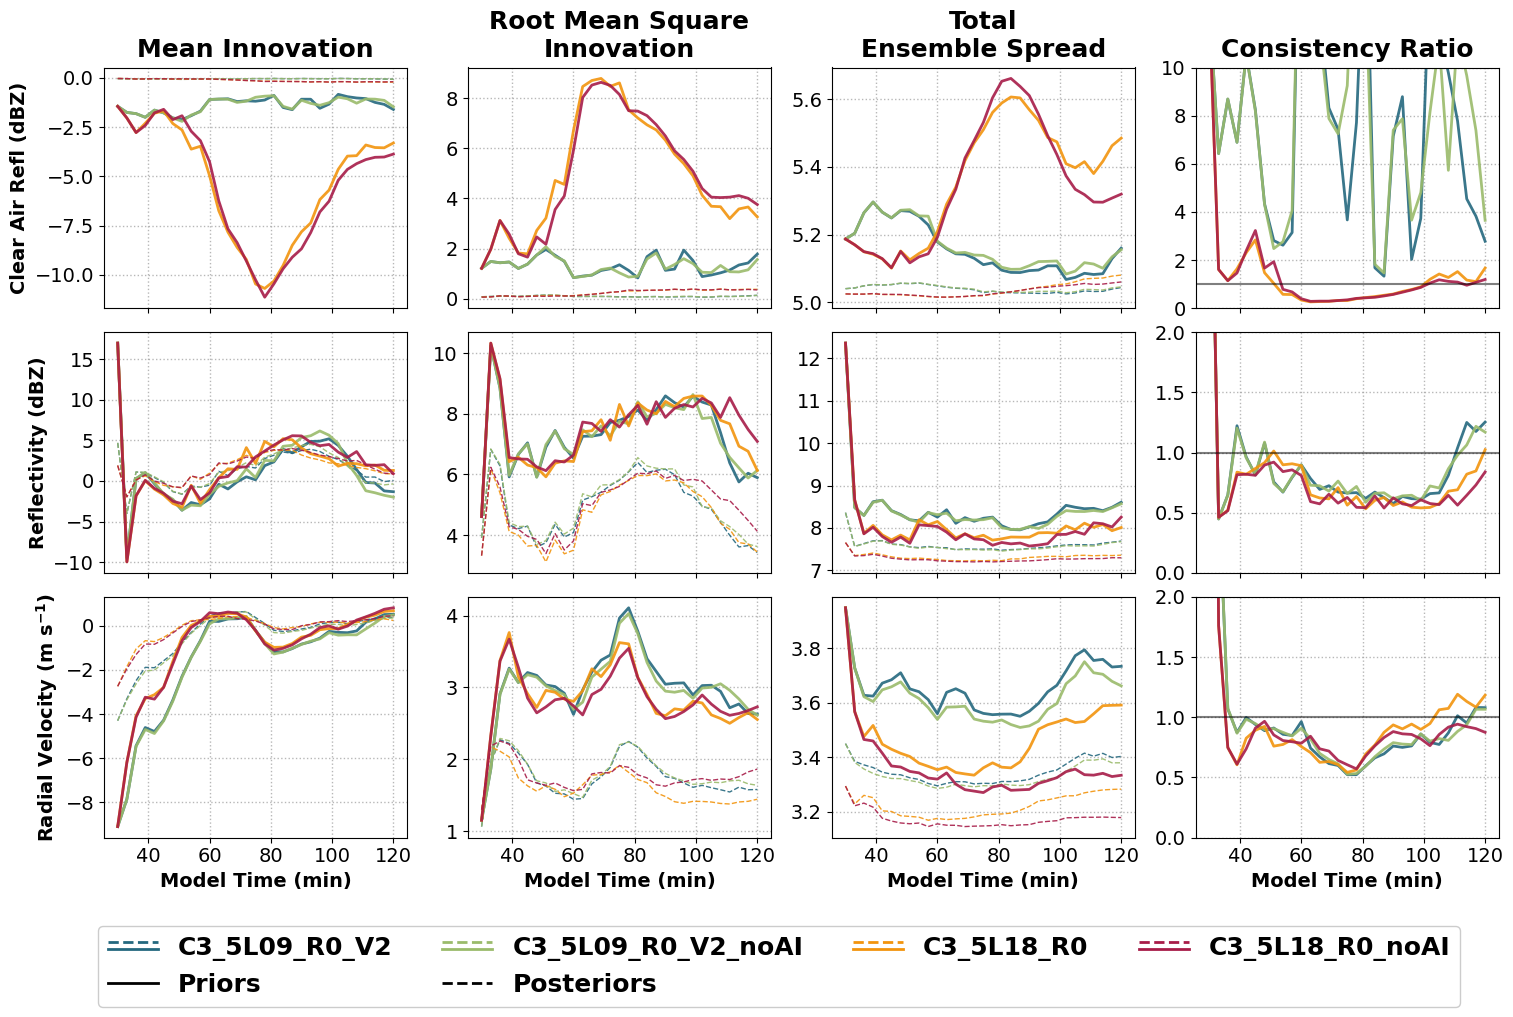

In [8]:

obs = [ 'DBZ0', 'DBZ', 'VR']

exps = [f'C3_5L{h:02d}_R0' for h in [9,18]]

exps = ['C3_5L09_R0_V2', 'C3_5L09_R0_V2_noAI','C3_5L18_R0','C3_5L18_R0_noAI']

colors=cmaps.pride(np.linspace(.2, .8, len(exps)))
if len(exps)>6:colors = cmaps.pride(np.linspace(.02, .8, len(exps)))

fig,axes = plt.subplots(3,4, figsize=(18,10), sharex=True)


axes[0,0].set_title('Mean Innovation', weight='bold', y=1.01)
axes[0,1].set_title('Root Mean Square\nInnovation', weight='bold', y=1.01)
axes[0,2].set_title('Total\nEnsemble Spread', weight='bold', y=1.01)
axes[0,3].set_title('Consistency Ratio', weight='bold', y=1.01)

max_CR=[]

for i,exp in enumerate(exps):
    color = colors[i]
    fpath  = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp

    for ii,var in enumerate(obs):

        
        dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, fpath)
        
        axes[ii,0].plot(dates, IN, lw=2, alpha=0.9,color=color,label=exp)
        axes[ii,0].plot(dates, INpost, lw=1, alpha=0.9,ls='--', color=color,label=exp)
        
        axes[ii,1].plot(dates, RMSI, lw=2, alpha=0.9,color=color,label=exp)
        axes[ii,1].plot(dates, RMSIpost, lw=1, alpha=0.9,ls='--',color=color,label=exp)
        
        axes[ii,2].plot(dates, SPRD, lw=2, alpha=0.9,color=color,label=exp)
        axes[ii,2].plot(dates, SPRDpost, lw=1, alpha=0.9,ls='--',color=color,label=exp)
        
        axes[ii,3].plot(dates, CR,   lw=2, alpha=0.9,color=color,label=exp)

dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exps[0])
# formatting
plt.subplots_adjust(hspace=0.1)
for ax in axes[-1,:].flatten():
    #format_time_ticks(ax, dates, fontsize=12, approx_number_of_ticks=6, tick_format='%H%M')
    ax.set_xlabel('Model Time (min)')
    
for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
# for ax in axes[:,[0,1,2]].flatten():
#     ax.axhline(0, ls='-', color='k', alpha=0.5)
for ax in axes[:,3].flatten():
    ax.axhline(1, ls='-', color='k', alpha=0.5)


axes[0,3].set_ylim(0, 10)
axes[1,3].set_ylim(0, 2)
axes[2,3].set_ylim(0, 2)

#axes[1,1].set_xlim(30, 40)

if "DBZ0_W" in obs:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ->W)', weight='bold');
else:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');

axes[1,0].set_ylabel('Reflectivity (dBZ)', weight='bold');
axes[2,0].set_ylabel(r'Radial Velocity (m s$\mathbf{^{-1}}$)', weight='bold');

_, labels = plt.gca().get_legend_handles_labels()

llen = len(exps)

if llen > 1:

    bbox = (0.5, -0.072)

    handles = []
    for i in range(llen): 
        handles.append((colors[i], '--',2))
        
    new_labels = ['']*llen*2
    new_handles = [('w', '-', 2, 'textonly')]*llen*2
    
    for i in np.arange(0, llen*2, 2):
        new_labels[i] = labels[int(i/2)]
        new_handles[i] = handles[int(i/2)]
        if i == 0:
            new_labels[1] = 'Priors'
            new_handles[1] = ('k', '-', 2, 'prior')
        if i == 2:
            new_labels[3] = 'Posteriors'
            new_handles[3] = ('k', '--', 2, 'post')

else:

    bbox = (0.5, -0.032)
    labels.extend(['Prior','Posterior'])
    handles.extend([('k', '-', 2, 'prior'), ('k', '--', 2, 'post')])
    new_labels, new_handles = labels, handles
    llen=3

leg = fig.legend(new_handles, new_labels,  handler_map={tuple:AnyObjectHandler()},
           prop={'size':18, 'weight':'bold'}, loc='lower center', ncol=llen, bbox_to_anchor=bbox,)


In [10]:
#inf = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L09_R0/Inflation_2024-05-08_20:00:00.nc')
np.prod(np.shape(inf.inflation))

np.int64(851968)

In [11]:
52*128*128

851968

C3_5L07_R0
C3_5L09_R0
C3_5L12_R0
C3_5L15_R0
C3_5L18_R0


(0.3, 0.65)

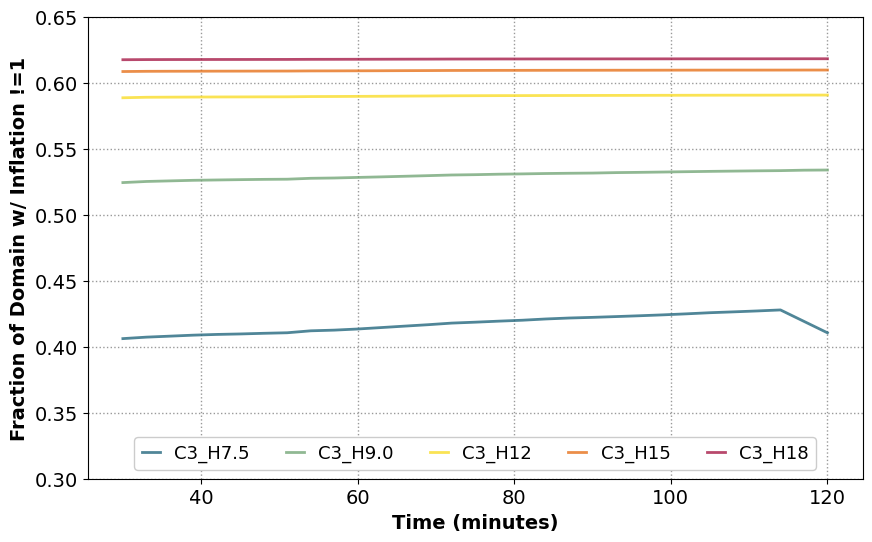

In [20]:
exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]
name='H'

colors=cmaps.pride(np.linspace(.2, .8, len(exps)))

fig = plt.figure(figsize=(10, 6))

for i, exp in enumerate(exps):
    print(exp)


    files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
    time=[]
    mean=[]
    for f in files:
        time.append((dt.datetime.strptime(f.split('Inflation_')[1], '%Y-%m-%d_%H:%M:%S.nc') - dt.datetime(2024,5,8,19,30)).seconds)
        inf = xr.open_dataset(f)
        total = np.prod(np.shape(inf.inflation))
        mean.append(np.count_nonzero(inf.inflation.values.flatten() != 1.0)/total)
        inf.close()
    plt.plot(np.array(time)/60, mean, label=rename(exp, version=name), color=colors[i], lw=2, alpha=0.8)


plt.legend(fontsize=13, loc="lower center", ncol=5, handlelength = 1)
plt.xlabel('Time (minutes)')
plt.ylabel('Fraction of Domain w/ Inflation !=1')
plt.grid()
plt.ylim(0.3, 0.65)

C3_5L07_R0
C3_5L09_R0
C3_5L12_R0
C3_5L15_R0
C3_5L18_R0


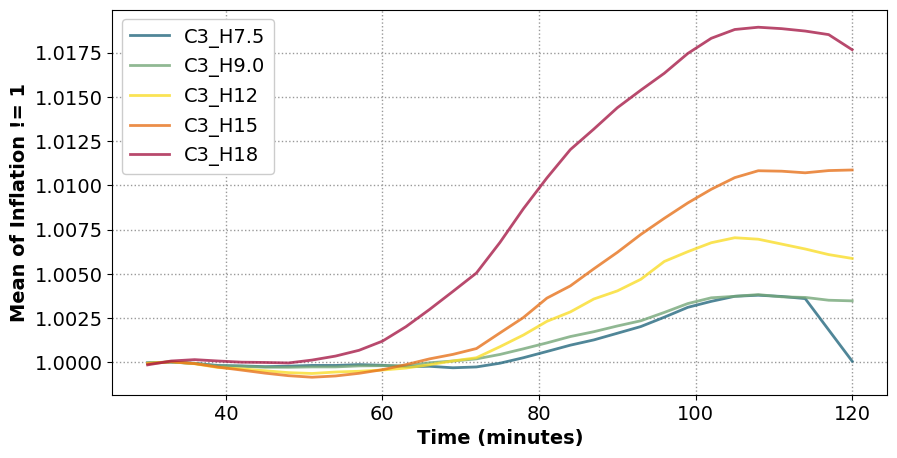

In [21]:
exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]
name='H'

colors=cmaps.pride(np.linspace(.2, .8, len(exps)))

fig = plt.figure(figsize=(10, 5))

for i, exp in enumerate(exps):
    print(exp)


    files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
    time=[]
    mean=[]
    for f in files:
        time.append((dt.datetime.strptime(f.split('Inflation_')[1], '%Y-%m-%d_%H:%M:%S.nc') - dt.datetime(2024,5,8,19,30)).seconds)
        inf = xr.open_dataset(f)
        new = np.where(inf.inflation.values == 1.0, np.nan, inf.inflation)
        mean.append(np.nanmean(new))
        inf.close()
    plt.plot(np.array(time)/60, mean, label=rename(exp, version=name), color=colors[i], lw=2, alpha=0.8)



plt.legend(fontsize=14)
plt.xlabel('Time (minutes)')
plt.ylabel('Mean of Inflation != 1')
plt.grid()

C3_5L07_R0
C3_5L09_R0
C3_5L12_R0
C3_5L15_R0
C3_5L18_R0


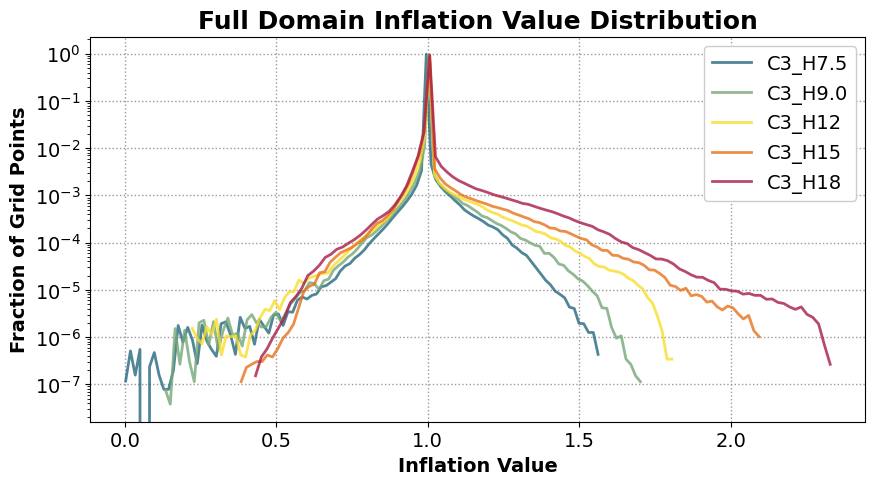

In [15]:
def plot_distribution(ax, var, **kwargs):
    hist, bins = np.histogram(var, bins=100)
    bins = (bins[1:]+bins[:-1])/2.0
    ax.semilogy(bins, hist / len(var),**kwargs)

exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]
name='H'

colors=cmaps.pride(np.linspace(.2, .8, len(exps)))

fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i, exp in enumerate(exps):
    print(exp)


    files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
    time=[]
    mean=[]
    for f in files:
        time.append((dt.datetime.strptime(f.split('Inflation_')[1], '%Y-%m-%d_%H:%M:%S.nc') - dt.datetime(2024,5,8,19,30)).seconds)
        inf = xr.open_dataset(f)
        #new = np.where(inf.inflation.values == 1.0, np.nan, inf.inflation)
        mean.extend(inf.inflation.values.flatten())
        inf.close()
    #plt.plot(np.array(time)/60, mean, label=rename(exp, version=name), color=colors[i], lw=2, alpha=0.8)
    plot_distribution(ax, mean, label=rename(exp, version=name), color=colors[i], lw=2, alpha=0.8)



plt.legend(fontsize=14)
plt.xlabel('Inflation Value')
plt.ylabel('Fraction of Grid Points')
ax.set_title('Full Domain Inflation Value Distribution', weight='bold')
plt.grid()

In [5]:
my_array = np.array([1, 2, 3, 4, 5, 3, 6])
value_to_exclude = 3
count = np.count_nonzero(my_array != value_to_exclude)
print(f"Count of values not equal to {value_to_exclude}: {count}")

Count of values not equal to 3: 5


C3_5L07_R0
C3_5L09_R0
C3_5L12_R0
C3_5L15_R0
C3_5L18_R0
C3_5L09_R0_V2


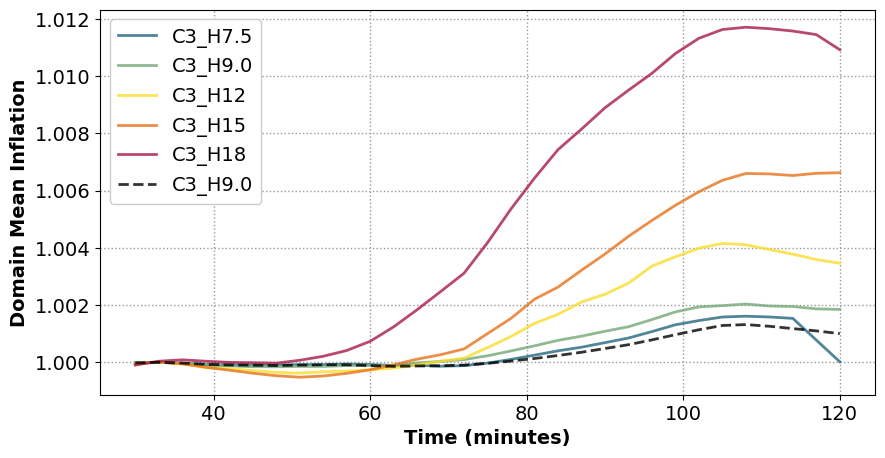

In [12]:
exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]
name='H'

colors=cmaps.pride(np.linspace(.2, .8, len(exps)))

fig = plt.figure(figsize=(10, 5))

for i, exp in enumerate(exps):
    print(exp)


    files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
    time=[]
    mean=[]
    for f in files:
        time.append((dt.datetime.strptime(f.split('Inflation_')[1], '%Y-%m-%d_%H:%M:%S.nc') - dt.datetime(2024,5,8,19,30)).seconds)
        inf = xr.open_dataset(f)
        mean.append(inf.inflation.mean().values)
        inf.close()
    plt.plot(np.array(time)/60, mean, label=rename(exp, version=name), color=colors[i], lw=2, alpha=0.8)


for i, exp in enumerate(['C3_5L09_R0_V2']):
    print(exp)


    files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
    time=[]
    mean=[]
    for f in files:
        time.append((dt.datetime.strptime(f.split('Inflation_')[1], '%Y-%m-%d_%H:%M:%S.nc') - dt.datetime(2024,5,8,19,30)).seconds)
        inf = xr.open_dataset(f)
        mean.append(inf.inflation.mean().values)
        inf.close()
    plt.plot(np.array(time)/60, mean, label=rename(exp, version=name), color='k',ls='--', lw=2, alpha=0.8)
plt.legend(fontsize=14)
plt.xlabel('Time (minutes)')
plt.ylabel('Domain Mean Inflation')
plt.grid()

In [8]:
var='DBZ'

def plot_obs_stats(exp, var, inlier=False):
    ds = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/AllPrior_Post.nc", decode_timedelta=True)
    times = [pd.Timestamp(t) for t in ds.time.values]    
    val = get_var(ds, 'value', var, drop_inliers=inlier)
    
    Hxfbar = get_var(ds, 'Hxfbar', var,drop_inliers=inlier)
    Hxf = get_var(ds, 'Hxf', var, drop_inliers=inlier)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var, drop_inliers=inlier)
    Hxf_post = get_var(ds, 'Hxf_post', var, drop_inliers=inlier)
    
    obs_var = get_var(ds, 'error',var, drop_inliers=inlier) ### NOTE - THIS IS ALREADY SQUARED!
    
    outlier = get_var(ds, 'outlier', var, drop_inliers=inlier)
    
    d = val - Hxfbar ## identical
    
    # if var =='DBZ0':
    #     # mask = (d!=0.0)
    #     # d = d[mask]
    #     d[d==0.0] = np.nan
        
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical
    
    Hxf_var_post = np.nanmean(np.nanvar(Hxf_post, ddof=1, axis=2),axis=1) ##identical
    
    rmsi      = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    rmsi_post = np.nanmean(np.sqrt((d_post-np.nanmean(d_post, axis=1)[:,np.newaxis])**2), axis=1) 
    
    spread      = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    spread_post = np.sqrt(np.nanmax(obs_var) + Hxf_var_post)
    
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 
    
    # obs counts
    outlier = get_var(ds, 'outlier', var, drop_outliers=False)

    if inlier == False:
        Nobs_reject = np.count_nonzero(outlier > 3, axis=1).astype(float)
        Nobs_assim = np.count_nonzero(outlier <= 3, axis=1).astype(float)
        Nobs = Nobs_reject+Nobs_assim
        
        Nobs_reject[np.where(Nobs_reject == 0.0)] = np.nan
        Nobs_assim[Nobs_assim == 0.0] = np.nan
    if inlier:
        
        Nobs_out= np.count_nonzero(outlier > 3, axis=1).astype(float)
        Nobs_in = np.count_nonzero(outlier < 0.25, axis=1).astype(float)
        Nobs = np.count_nonzero(np.isnan(outlier)==False, axis=1).astype(float)
        Nobs_reject = Nobs_out+Nobs_in
        
        Nobs_assim = Nobs - Nobs_reject
    
    
    obs_err = np.sqrt(np.nanmax(obs_var))
    
    c = cmaps.ember(np.linspace(.3, .8, 3))
    c = cmaps.torch(np.linspace(.3, .8, 3))
    c = cmaps.sunburst(np.linspace(.2, .7, 3))

    c = cmaps.lipari(np.linspace(.24, .8, 3))
    
    fig,axes=plt.subplots(2,2,figsize=(14,10), sharex=True)
    
    #----------------------
    axes[0,0].plot(times, inno,      lw=2,color=c[0],label='prior innov.' )
    axes[0,0].plot(times, inno_post, lw=2,ls='--', color=c[0], label='post innov.' )
    
    axes[0,0].plot(times, rmsi,     lw=2, color=c[1], label='prior rmsi')
    axes[0,0].plot(times, rmsi_post,lw=2, color=c[1],ls='--', label='post rmsi')
    
    axes[0,0].plot(times, spread,     lw=2, color=c[2], label='prior spread')
    axes[0,0].plot(times, spread_post,lw=2, color=c[2],ls='--', label='post spread')
    
    pl = axes[0,0].plot(times, [obs_err]*len(times), color='k', lw=3, alpha=0.3)
    #----------------------
    
    axes[0,1].plot(times, crt, color=c[0], lw=3)
    axes[0,1].axhline(1, ls=':', color='k')
    #----------------------

    axes[1,0].plot(times, [obs_err]*len(times), label='ob error', color='k', lw=3, alpha=0.3)
    axes[1,0].plot(times, inno, color=c[0],     lw=2,label='y - Hxf')
    axes[1,0].plot(times, np.sqrt(Hxf_var),     lw=2, color=c[1],label='stdev Hxf')
    #----------------------
    
    axes[1,1].plot(times,Nobs,        color=c[0], lw=4, label='Total')
    axes[1,1].plot(times,Nobs_assim,  color=c[2], lw=2,label='Assimilated')
    axes[1,1].plot(times,Nobs_reject, color=c[1], lw=2,label='Rejected')
    
    
    ## legends
    axes[0,0].legend(fontsize=12,ncol=3, handlelength=1.5, loc='upper center', bbox_to_anchor=(.5, 1.15))
    axes[1,0].legend(fontsize=14,ncol=3, handlelength=1.5, loc='upper center', bbox_to_anchor=(.5, 1.1))
    axes[1,1].legend(fontsize=14,ncol=3, handlelength=1.5, loc='upper center', bbox_to_anchor=(.5, 1.1))
    
    
    # formatting and labels
    format_time_ticks(axes[1,0], times, fontsize=12, approx_number_of_ticks=7, tick_format='%H%M')
    format_time_ticks(axes[1,1], times, fontsize=12, approx_number_of_ticks=7, tick_format='%H%M')
    plt.subplots_adjust(hspace=0.13)
    
    axes[0,0].set_ylabel('dBZ')
    axes[0,1].set_ylabel('Consistency Ratio')
    axes[1,1].set_ylabel('N Observations')
    axes[1,0].set_ylabel('dBZ')

    axes[0,1].set_ylim(-1, 15)
    
    
    axes[1,0].set_xlabel('Time (HHMM UTC)')
    axes[1,1].set_xlabel('Time (HHMM UTC)')
    
    for ax in axes.flatten():
        ax.grid(ls=':', alpha=0.7, color='0.7')
    
    fig.suptitle(f'\"{var}\" Statistics for {os.path.basename(exp)}',fontsize=20, weight='bold', y=.97)


In [5]:
exp = 'CI_10min'

var = 'VR'

plot_obs_stats(exp, var, inlier=False)


exp = 'CI_10min_loc2'

var = 'VR'

plot_obs_stats(exp, var, inlier=False)


NameError: name 'plot_obs_stats' is not defined

In [25]:




def get_counts(exp, var, inlier=False):
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    with open(os.path.join(exp, 'letkf.exp'), 'rb') as f: exper = json.load(f)
    start = DT.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
    times = [(pd.Timestamp(t)-start).seconds/60 for t in ds.time.values]     
    
    
    # obs counts
    outlier = get_var(ds, 'outlier', var, drop_outliers=False)
    Nobs_out= np.count_nonzero(outlier > 3, axis=1).astype(float)
    Nobs_in = np.count_nonzero(outlier < 0.25, axis=1).astype(float)
    Nobs = np.count_nonzero(np.isnan(outlier)==False, axis=1).astype(float)

    if inlier == False: Nobs_in = Nobs_in * 0
        
    Nobs_assim = Nobs - (Nobs_out+Nobs_in)
        
    Nobs_out[np.where(Nobs_out == 0.0)] = np.nan
    Nobs_assim[Nobs_assim == 0.0] = np.nan
    Nobs_in[np.where(Nobs_in == 0.0)] = np.nan


    return times, Nobs, Nobs_assim, Nobs_out, Nobs_in
    


Text(0.5, 1.4, 'Observation Counts')

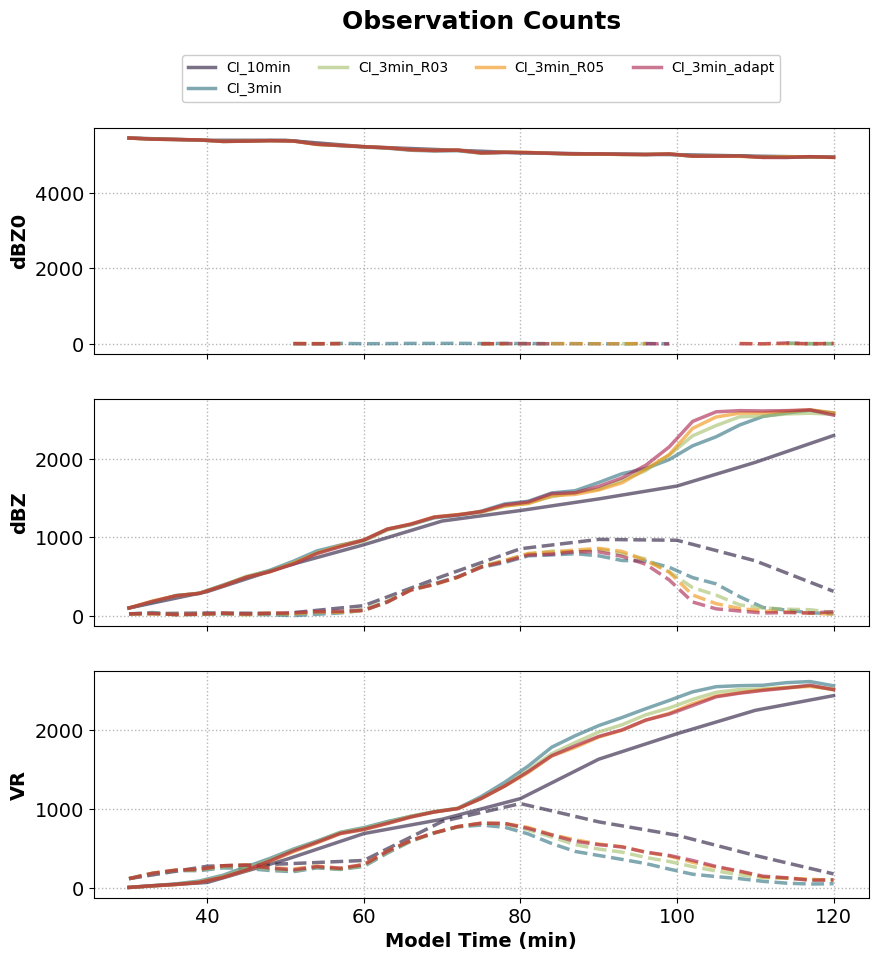

In [19]:
exps = ['CI_10min', 'CI_3min']

exps = ['CI_10min','CI_3min','CI_3min_adapt','CI_3min_R01', 'CI_3min_R03', 'CI_3min_R05','CI_3min_R07', 'CI_3min_R09']

exps = ['CI_10min','CI_3min', 'CI_3min_R03', 'CI_3min_R05','CI_3min_adapt',]

colors = cmaps.pride(np.linspace(.02, .8, len(exps)))


fig, axes = plt.subplots(3,1, figsize=(10,10), sharex=True, sharey='row')


# fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min'
# for ax, var in zip(axes, ['DBZ0', 'DBZ', 'VR']):
#     times, Nobs, Nobs_assim, Nobs_out, Nobs_in = get_counts(fpath, var, inlier=False)
#     ax.plot(times, Nobs_assim, color='k', alpha=0.6, label=f'CI_10min')
#     ax.plot(times, Nobs_out,   color='k', alpha=0.6, ls='--', )
#     ax.grid(ls=':', alpha=0.7)
    

for i,exp in enumerate(exps):
    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp
    for ax, var in zip(axes, ['DBZ0', 'DBZ', 'VR']):
        times, Nobs, Nobs_assim, Nobs_out, Nobs_in = get_counts(fpath, var, inlier=False)
        ax.plot(times, Nobs_assim, color=colors[i],lw=2.5, alpha=0.6, label=f'{exp}')
        ax.plot(times, Nobs_out,   color=colors[i],lw=2.5, alpha=0.6, ls='--', )
        ax.grid(ls=':', alpha=0.7)




axes[0].legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.35))
axes[0].set_ylabel('dBZ0')
axes[1].set_ylabel('dBZ')
axes[2].set_ylabel('VR')
axes[2].set_xlabel('Model Time (min)')
axes[0].set_title('Observation Counts',y=1.4, weight='bold')     

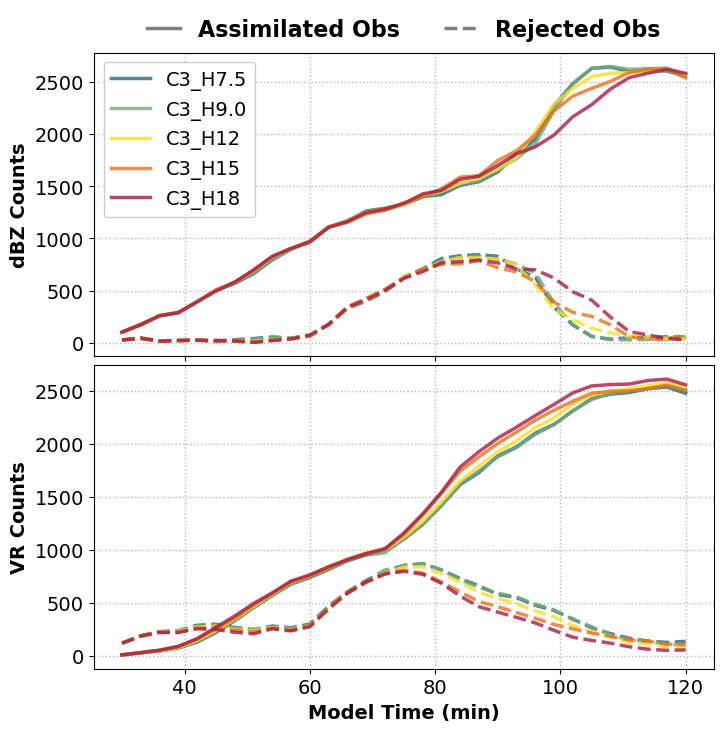

In [67]:

exps = ['CI_10min','CI_3min', 'CI_3min_R03', 'CI_3min_R05','CI_3min_adapt',]
exps = [f'C10_h{h:02d}_R0' for h in [7,9,12,15,18]]

exps = [f'C{h}_5L18_R0' for h in [15,10,3]]


names = 'CI'


colors = cmaps.pride(np.linspace(.02, .8, len(exps)))
colors = cmaps.pride([.2, .6, .8])

exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]

colors=cmaps.pride(np.linspace(.2, .8, len(exps)))
names='H'

fig, axes = plt.subplots(2,1, figsize=(8,8), sharex=True, sharey='row')


for i,exp in enumerate(exps):
    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp
    for ax, var in zip(axes, [ 'DBZ', 'VR']):
        times, Nobs, Nobs_assim, Nobs_out, Nobs_in = get_counts(fpath, var, inlier=False)
        #print(Nobs_in)
        ax.plot(times, Nobs_assim, color=colors[i],lw=2.5, alpha=0.8, label=rename(exp, version=names.upper()))
        ax.plot(times, Nobs_out,   color=colors[i],lw=2.5, alpha=0.8, ls='--', )
        ax.grid(ls=':', alpha=0.7)




#axes[0].legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.12), handlelength=2, fontsize=16)
axes[0].legend(fontsize=14,loc=2)#, bbox_to_anchor=(0.5, 1.12), handlelength=2, fontsize=16)

l1 = mpl.lines.Line2D([0], [0], label='Assimilated', color='Gray', linewidth=2.5)
l2 = mpl.lines.Line2D([0], [0], label='Rejected', color='Gray', linewidth=2.5, ls='--')
axes[1].legend([l1,l2], ['Assimilated Obs', 'Rejected Obs'],handlelength=1.5, ncol=2,
               loc='upper center', prop={'size':16,'weight':'bold'}, bbox_to_anchor=(0.5, 2.21), frameon=False)

axes[0].set_ylabel('dBZ Counts')
axes[1].set_ylabel('VR Counts')
axes[1].set_xlabel('Model Time (min)')
#axes[0].set_title('Observation Counts',y=1.15, weight='bold') 
plt.subplots_adjust(hspace=0.03)

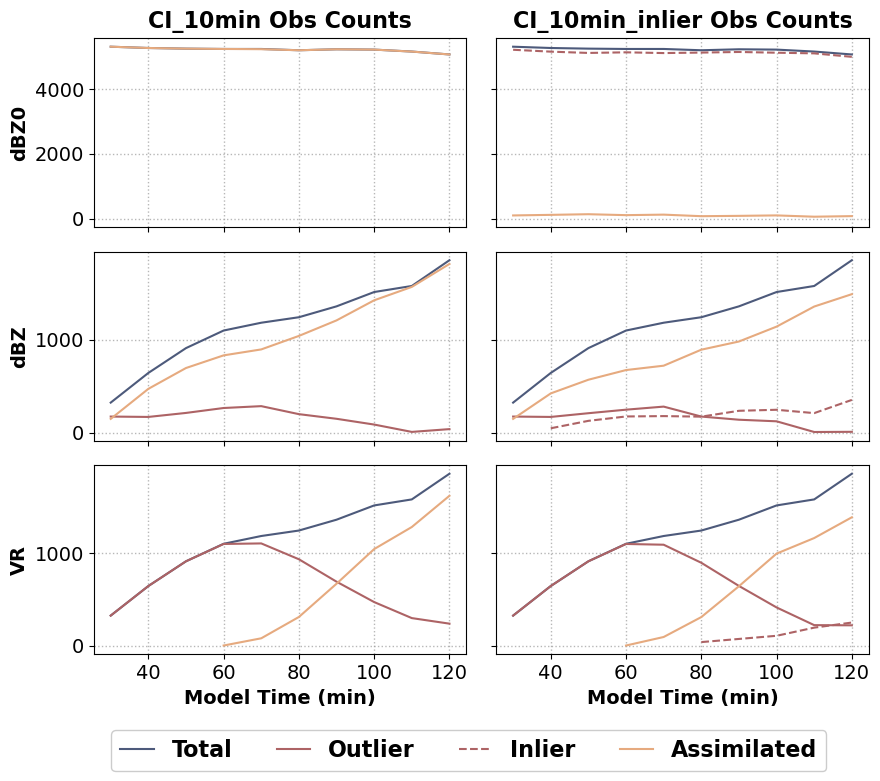

In [65]:
obs = ['DBZ0', 'DBZ', 'VR']


exps = ['CI_3min', 'CI_3min_inlier', 'CI_3min_err_inlier']
exps = ['CI_10min', 'CI_10min_inlier']

if len(exps) == 3:
    fig, axes = plt.subplots(3,3, figsize=(14, 8), sharex=True, sharey='row')

if len(exps) == 2:
    fig, axes = plt.subplots(3,2, figsize=(10, 8), sharex=True, sharey='row')
    
c = cmaps.lipari(np.linspace(.24, .8, 3))

inlier=False
for i, exp in enumerate(exps):
    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp
    if i == 1:
        inlier=True

    axes[0,i].set_title(os.path.basename(exp)+ ' Obs Counts', fontsize=16, y=1.01, weight='bold')

    for ax, var in zip(axes[:,i], obs):
        

        times, Nobs, Nobs_assim, Nobs_out, Nobs_in = get_counts(fpath, var, inlier=inlier)
        ax.plot(times, Nobs, color=c[0], label='Total')
        ax.plot(times, Nobs_out, color=c[1], label='Outlier')
        ax.plot(times, Nobs_in, color=c[1], ls='--', label='Inlier')
        ax.plot(times, Nobs_assim, color=c[2], label='Assimilated')
        ax.grid(ls=':', alpha=0.7)


plt.subplots_adjust(hspace=0.13, wspace=0.08)
    
axes[0,0].set_ylabel('dBZ0')
axes[1,0].set_ylabel('dBZ')
axes[2,0].set_ylabel('VR')


for ax in axes[2,:].flatten():
    ax.set_xlabel('Model Time (min)')


handles, labels = plt.gca().get_legend_handles_labels()

fig.legend(handles, labels, prop={'size':16, 'weight':'bold'},ncol=4,  handlelength=1.5, loc='lower center', bbox_to_anchor=(0.5, -.05))

In [546]:
exp = 'CI_3min'

ds = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/AllPrior_Post.nc", decode_timedelta=True)

dbz = get_var(ds, "value", 'DBZ0')   
lat = get_var(ds, "y", 'DBZ0') 
lon = get_var(ds, "x", 'DBZ0') 
z = get_var(ds, "z", 'DBZ0')
ds.time.values

array(['2024-05-08T20:00:00.000000000', '2024-05-08T20:03:00.000000000',
       '2024-05-08T20:06:00.000000000', '2024-05-08T20:09:00.000000000',
       '2024-05-08T20:12:00.000000000', '2024-05-08T20:15:00.000000000',
       '2024-05-08T20:18:00.000000000', '2024-05-08T20:21:00.000000000',
       '2024-05-08T20:24:00.000000000', '2024-05-08T20:27:00.000000000',
       '2024-05-08T20:30:00.000000000', '2024-05-08T20:33:00.000000000',
       '2024-05-08T20:36:00.000000000', '2024-05-08T20:39:00.000000000',
       '2024-05-08T20:42:00.000000000', '2024-05-08T20:45:00.000000000',
       '2024-05-08T20:48:00.000000000', '2024-05-08T20:51:00.000000000',
       '2024-05-08T20:54:00.000000000', '2024-05-08T20:57:00.000000000',
       '2024-05-08T21:00:00.000000000', '2024-05-08T21:03:00.000000000',
       '2024-05-08T21:06:00.000000000', '2024-05-08T21:09:00.000000000',
       '2024-05-08T21:12:00.000000000', '2024-05-08T21:15:00.000000000',
       '2024-05-08T21:18:00.000000000', '2024-05-08

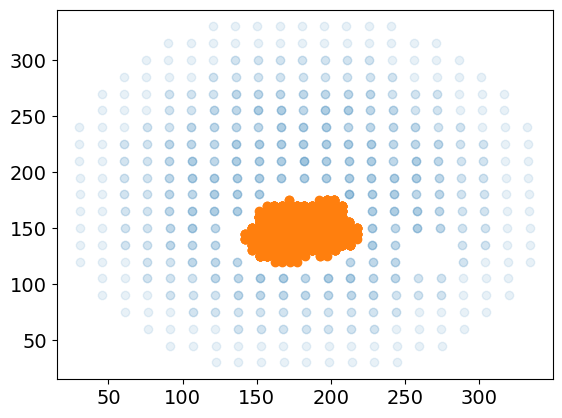

In [557]:
t=15


dbz = get_var(ds, "value", 'DBZ0')   
lat = get_var(ds, "y", 'DBZ0') 
lon = get_var(ds, "x", 'DBZ0') 
z = get_var(ds, "z", 'DBZ0')

mask = (z[t] > 1000 )& (z[t]< 3000)
plt.scatter(lon[t, mask]/1000, lat[t, mask]/1000, alpha=0.1)#dbz[t,:]


dbz = get_var(ds, "value", 'DBZ')   
lat = get_var(ds, "y", 'DBZ') 
lon = get_var(ds, "x", 'DBZ') 
#z = get_var(ds, "z", 'DBZ')
#mask = (z[t] > 1000 )& (z[t]< 3000)
plt.scatter(lon[t]/1000, lat[t]/1000, alpha=1)


In [536]:
np.shape(lat)

(31, 5316)

# Weak Temperature Gradient Approximation

In [ ]:
python stats_calc.py -e /work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control_60/Control_60.exp -w

Text(0.5, 1.06, 'Control Run (no DA) 30-180 Minutes')

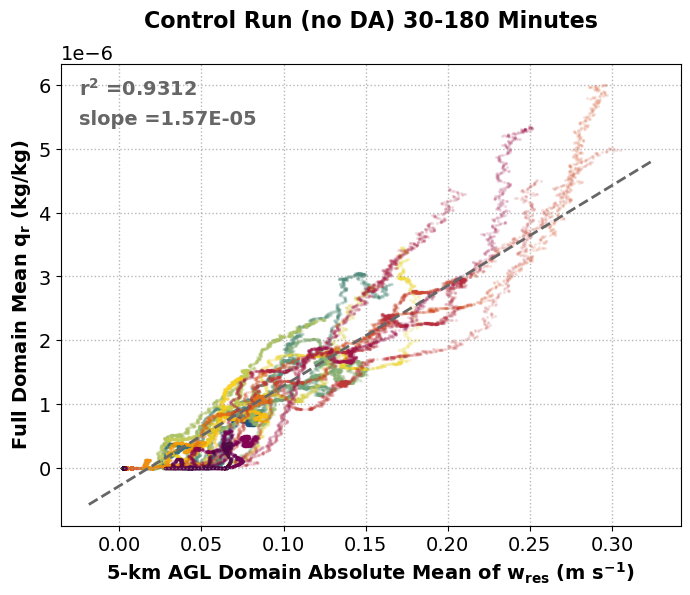

In [28]:

fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
control = xr.open_dataset(f'{fpath}Control/balance.nc')

ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())

fig,ax=plt.subplots(figsize=(8,6))

members = np.arange(0, 36, 1)

colors=cmaps.cet_g_bw_minc_minl(np.linspace(0,1,256))
colors=cmaps.cet_g_bw_minc_minl(np.linspace(0,1,256))
colors=cmaps.pride(np.linspace(.15,.95,len(members)))
#colors=cmaps.cet_g_category10(np.linspace(0,1,256))


for m in members:
    ax.scatter(control.wres[ti:tti+1,m], control.qr[ti:tti+1,m],  s=2, alpha=.1, color=colors[m])#color=colors[m+70])

plot_regression(ax, control.wres[ti:tti+1,:].values.ravel(), control.qr[ti:tti+1,:].values.ravel())


ax.set_ylabel(r'Full Domain Mean q$\mathbf{_r}$ (kg/kg)');
ax.set_xlabel(r'5-km AGL Domain Absolute Mean of w$\mathbf{_{res}}$ (m s$\mathbf{^{-1}}$)');

ax.grid(ls=':', alpha=0.7)

ax.set_title('Control Run (no DA) 30-180 Minutes', y=1.06, fontsize=16, weight='bold')

In [66]:
import datetime as dt

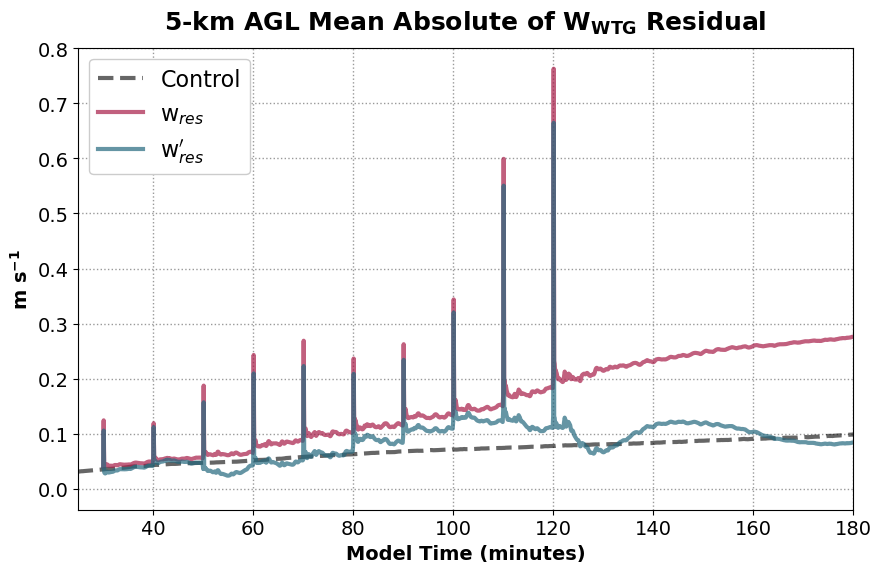

In [67]:
# weak tmperature gradient approx tests
# import scipy 

fig, ax = plt.subplots(1, figsize=(10,6))

fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

colors=cmaps.pride(np.linspace(.2, .8,2))

### WTG
control = xr.open_dataset(f'{fpath}Control/balance.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values

ax.plot(control.time, control.wres.mean(axis=1), color='k', label='Control', ls='--', lw=3, alpha=0.6)


ax.set_title("5-km AGL Mean Absolute of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
ax.set_xlabel('Model Time (minutes)')
ax.set_ylabel(r'm s$\mathbf{^{-1}}$');
# axes[0].grid(ls=':', alpha=0.7)

# axes[1].set_title("Lowest-Model Level Mean Absolute dP\'/dt", weight='bold', y=1.02)
# axes[1].set_xlabel('Model Time (minutes)')
# axes[1].set_ylabel(r'hPa  s$\mathbf{^{-1}}$');
# axes[1].grid(ls=':', alpha=0.7)

exps = ['C10_5L09_R0']


for i,exp in enumerate(exps): 

    # get da times
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    peaks = (np.arange(0,dalen+freq/2, freq )/6).astype(int) +1

    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120)+1
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]
    pten = wtg.divc.values[i0:].mean(axis=1)/100

    if np.shape(rain)[1]  >36:
        wtg_adjusted = (wres- (1/slope60)*(rain - control_rain60[ti:ti+len(rain)])).mean(axis=1)
    else:
        wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)

    # find the peaks 
    df = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted, "pten":pten, 'wtg':wres.mean(axis=1)}, index=time)
    df['pmax'] = df['pten'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    df['wmax'] = df['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    

    #### WTG
   # scat=axes[0].scatter(df.index.values[:i1][::int(freq/6)], df['wmax'].values[:i1][::int(freq/6)], color=colors[i], s=30,marker=markers[i], zorder=200+freq, ec='k')
    ax.plot(df.wtg,  color=colors[1], lw=3,alpha=0.7, label=r'w$_{res}$')
    ax.plot(df.wtg_adjusted,  color=colors[0], lw=3,alpha=0.7, label=r'w$_{res}^{\prime}$')


    #### PRESSURE TENDENCY
    # #scat=axes[1].scatter(df.index.values[:i1][::int(freq/6)], df['pmax'].values[:i1][::int(freq/6)], color=colors[i], s=30,marker=markers[i], zorder=200+freq, ec='k')
    # ax.plot(df.pten,  color=colors[i], lw=1.5,label=rename(exp, version=name), alpha=0.7)


# leg=axes[0].legend(fontsize=13, loc=2)
# for line in leg.get_lines():
#     line.set_linewidth(3.0)
    
# leg=axes[1].legend(fontsize=13, loc=2)
# for line in leg.get_lines():
#     line.set_linewidth(3.0)

ax.set_xlim(25, 180)
ax.legend(loc=2, fontsize=16)
ax.grid()

In [4]:
def rename(exp, version = 'RAW'):
    '''versions are FUll, H, V, CI, or RAW'''


    version = version.upper()

    if (exp!= 'Control') & (version !='RAW'):

        split = exp.split('_')
        e1 = split[0]
        e_extra = '' 
        
        H = int(split[1][2:])
        if   H == 7: e2 = 'H7.5'
        elif H == 9: e2 = 'H9.0'
        else:        e2 = f'H{H}'
        
        
        if len(split) == 3: 
            e3 = 'V4.5'
            eR = split[2]
            
        else:
            V = int(split[3][1:])
            if V == 2: e3 = 'V2.5'
            if V == 6: e3 = 'V6.5'
    
               
    
            if len(split) == 5:
                e_extra = f'_{split[4]}'
    
        if version=='FULL': name = f'{e1}_{e2}_{e3}'
        if version=='H':    name = f'{e1}_{e2}'
        if version=='V':    name = f'{e1}_{e3}'
    
        if version == 'RAW': name = exp
        if version == 'CI': name = e1
        if version == 'DENSITY' : name = f'{int(split[1][0])}km{e_extra}'
    else:
        if exp == 'Control': name = 'NoDA'
        else: name = exp
            

    return name


C3_5L09_R0_V2
C3_5L09_R0_V2_noAI
C3_5L18_R0
C3_5L18_R0_noAI


(25.0, 180.0)

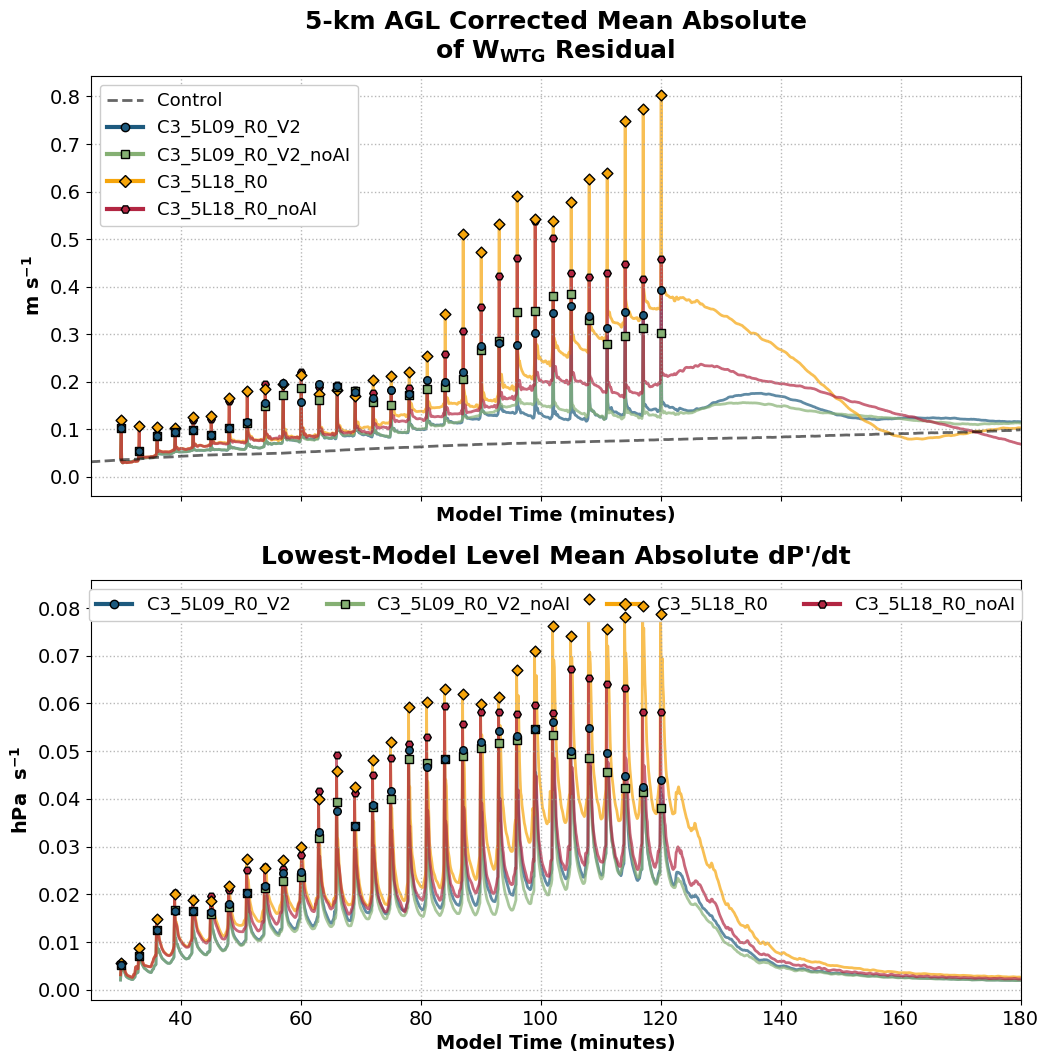

In [6]:


exps=['C10_5L09_R0_V2','C10_5L09_R0_V2_dense','C3_5L09_R0_V2','C3_5L09_R0_V2_dense']

exps = [f'C15_5L{h:02d}_R0' for h in [7,9,12,15,18]]

# exps = ['C15_5L18_R0']+[f'C3_5L{h:02d}_R0' for h in [7,9,12,15,18]]
# colors = ['k']+list(cmaps.pride(np.linspace(.17,.78, len(exps)-1)))
# markers = ['v','o', 's', 'D', 'H','^', '>', '<', 'v']
exps = ['C10_5L09_R0_V2','C10_5L09_R0_V2_lowtop'] #'C10_5L09_R0',
exps = ['C3_5L09_R0_V2', 'C3_5L09_R0_V2_noAI','C3_5L18_R0','C3_5L18_R0_noAI']

#exps = ['C3_5L09_R0_V2_noAI','C3_5L18_R0_noAI']


name='RAW'



members = np.arange(0, 36, 1)
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

colors = list(cmaps.pride(np.linspace(.17,.78, len(exps))))
if len(exps) == 3: colors = list(cmaps.pride([.2, .6, .8]))
markers = ['o', 's', 'D', 'H','^', '>', '<', 'v']
#fig,axes = plt.subplots(2,1, figsize=(18, 12), sharex=True)
fig,axes = plt.subplots(2,1, figsize=(12, 12), sharex=True)
#fig,axes = plt.subplots(2,1, figsize=(10, 12), sharex=True)

### WTG
control = xr.open_dataset(f'{fpath}Control/balance.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values

con=axes[0].plot(control.time, control.wres.mean(axis=1), color='k', label='Control', ls='--', lw=2, alpha=0.6)
   
axes[0].set_title("5-km AGL Corrected Mean Absolute\n"+r"of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
axes[0].set_xlabel('Model Time (minutes)')
axes[0].set_ylabel(r'm s$\mathbf{^{-1}}$');
axes[0].grid(ls=':', alpha=0.7)

axes[1].set_title("Lowest-Model Level Mean Absolute dP\'/dt", weight='bold', y=1.02)
axes[1].set_xlabel('Model Time (minutes)')
axes[1].set_ylabel(r'hPa  s$\mathbf{^{-1}}$');
axes[1].grid(ls=':', alpha=0.7)




for i,exp in enumerate(exps): 

    # get da times
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    peaks = (np.arange(0,dalen+freq/2, freq )/6).astype(int) +1

    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120)+1
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]
    pten = wtg.divc.values[i0:].mean(axis=1)/100
    #pten = wtg.divc.values[i0:][:,10]/100

    if np.shape(rain)[1]  >36:
        wtg_adjusted = (wres- (1/slope60)*(rain - control_rain60[ti:ti+len(rain)])).mean(axis=1)
    else:
        wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)
        #wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)]))[:,10]  #.mean(axis=1)

    # find the peaks 
    df = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted, "pten":pten}, index=time)
    df['pmax'] = df['pten'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    df['wmax'] = df['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    

    #### WTG
    zord = 1
    #if i == 0: zord=500
    scat=axes[0].scatter(df.index.values[:i1][::int(freq/6)]+.1, df['wmax'].values[:i1][::int(freq/6)], color=colors[i], s=30,marker=markers[i], zorder=100*(10-i), ec='k',label=rename(exp, version=name))
    print(exp)
    axes[0].plot(df.wtg_adjusted,  color=colors[i], lw=2,label=rename(exp, version=name), alpha=0.7, zorder=zord)#, zorder=100*(10-i))


    #### PRESSURE TENDENCY
    scat=axes[1].scatter(df.index.values[:i1][::int(freq/6)], df['pmax'].values[:i1][::int(freq/6)], color=colors[i], s=30,marker=markers[i], zorder=100*(10-i), ec='k',label=rename(exp, version=name))
    axes[1].plot(df.pten,  color=colors[i], lw=2,label=rename(exp, version=name), alpha=0.7, zorder=zord)#, zorder=100*(10-i))


handles, labels =axes[0].get_legend_handles_labels()
l = [labels[0]]
h = [handles[0]]
for i, exp in enumerate(exps):
    h.append(mpl.lines.Line2D([0], [0], color=colors[i], linewidth=3, marker=markers[i],  markeredgecolor='k'))
    l.append(rename(exp, version=name))
axes[0].legend(handles=h, labels=l,fontsize=13, loc=2)
axes[1].legend(handles=h[1:], labels=l[1:],fontsize=13, loc='upper center', ncol=4)


axes[0].set_xlim(25, 180)
#axes[0].set_xlim(28,55)

#axes[1].set_ylim(0,0.03)
# axes[1].axvline(30, color=colors[-1])
# axes[1].axvline(30+1.41, color=colors[-1])

# axes[1].axvline(30, color=colors[0])
# axes[1].axvline(30+2.12, color=colors[0])

# axes[1].axvline(90+.1, color=colors[-1]) # 60 seconds
# axes[1].axvline(90+1.8, color=colors[-1])
# axes[1].axvline(90+2.3, color=colors[-1])

# axes[1].axvline(90+2.4, color=colors[1])
# axes[1].axvline(90+3., color=colors[1]) # 132 seconds
# axes[1].axvline(90+6., color=colors[1]) # 132 seconds

In [90]:
2.12*60

127.2

In [12]:
2.2*60

# 132 s for 25 km height

# 60 s for 20 km height
# bounce = 6 sconds


# average height is 6.3 km

132.0

In [21]:
c = 343 #m/s
distance = 6300 + 100
distance/c

18.658892128279884

In [22]:
10000/c

29.154518950437318

In [19]:
# mean increment height is 6.3 km
# p field is at .1 km

In [58]:
import os, sys, argparse, cmath
import pylab as pl
import numpy as np
from scipy.fft import dct
from matplotlib import colors, ticker
import scipy.stats as stats

In [64]:


exps=['C10_5L09_R0', 'C3_5L09_R0','C2_5L09_R0','C1_5L09_R0']

exp=exps[0]
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')

stop = findnearest(wtg.time.values, 120)

time = wtg.time.values[:stop]
pten = wtg.divc[:stop].mean(axis=1)/100

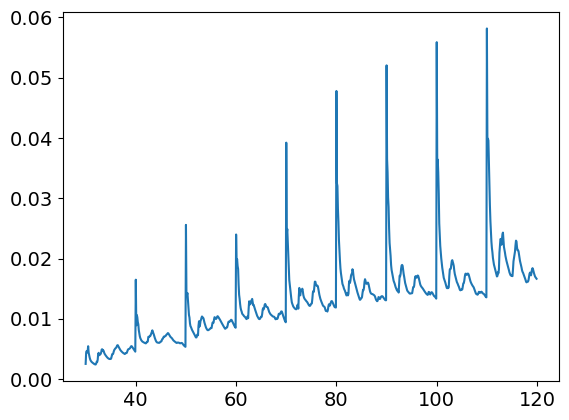

In [65]:
plt.plot(time, pten);

In [42]:
len(knrm)

5

In [43]:
len(variance)

450

In [61]:
_dct_type = 2

dt = 6 # 6 seconds
nt = len(pten)

variance = dct(pten, axis=0, type=_dct_type, norm='ortho')

kfreq   = np.fft.fftfreq(dt) * dt
knrm   = np.sqrt(kfreq**2)
knrm   = 0.5*(knrm[1:] + knrm[:-1])
knrm   = knrm[:nt//2]
#plt.plot(knrm)

variance2 = np.zeros(nt//2)

for i in np.arange(1, nt//2):
    variance2[i-1] = variance[2*i-1] + variance[2*i]
#plt.plot(variance)
#plt.plot(variance2)

variance = variance2

kbins = np.arange(0.5, nt//2+1, 1.)
kvals = 0.5 * (kbins[1:] + kbins[:-1])
PSbins, _, _ = stats.binned_statistic(knrm, variance, statistic = "mean", bins = kbins)

PSbins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

waven = 2.*kvals / nx

plt.plot(PSbins)

AttributeError: The number of `values` elements must match the length of each `sample` dimension.

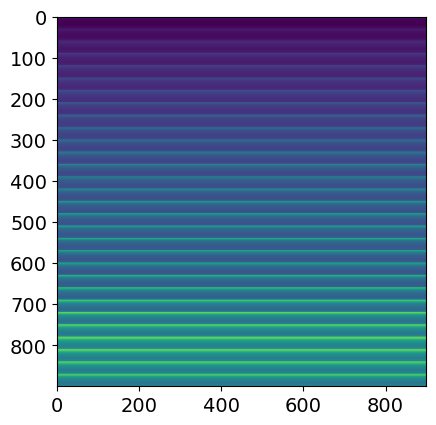

In [60]:
plt.imshow(v)

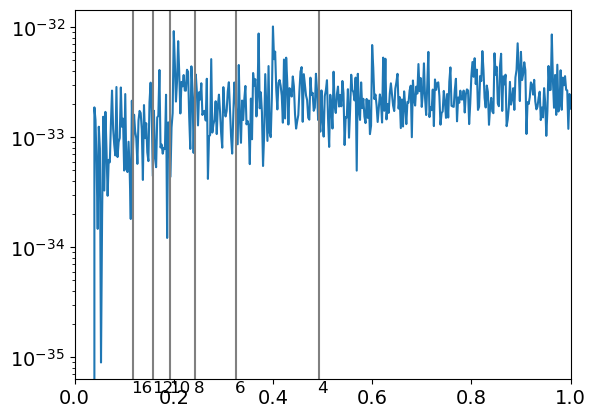

In [62]:
u,v = np.meshgrid(pten, pten)
nx, ny = np.shape(u)


variance = 0.5*dct(dct(u, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2
# variance = 0.5*(dct(dct(u, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2 \
#                        +dct(dct(v, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2)

kfreq   = np.fft.fftfreq(nx) * nx
kfreq2D = np.meshgrid(kfreq, kfreq)

knrm   = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
knrm2  = 0.5*(knrm[1:,:] + knrm[:-1,:])
knrm   = 0.5*(knrm2[:,1:] + knrm2[:,:-1])
knrm   = knrm[:nt//2,:nt//2].flatten()


variance2 = np.zeros((ny,nx//2))
variance3 = np.zeros((ny//2,nx//2))

for i in np.arange(1,nx//2):   
    variance2[:,i-1] = variance[:,2*i-1] + variance[:,2*i]

for j in np.arange(1,ny//2):   
    variance3[j-1,:] = variance2[2*j-1,:] + variance2[2*j,:]

variance = variance3.flatten()

kbins = np.arange(0.5, nx//2+1, 1.)
kvals = 0.5 * (kbins[1:] + kbins[:-1])
PSbins, _, _ = stats.binned_statistic(knrm, variance, statistic = "mean", bins = kbins)

PSbins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

waven = 2.*kvals / nx

plt.semilogy(waven, PSbins)
plt.xlim(0.0, 1.0)

for w in [4.0, 6.0, 8.0, 10.0, 12.0, 16.0]:
    plt.annotate(r"%d" % int(w), xy = (2.0/w-0.01, -0.035), xycoords='axes fraction', color='k',fontsize=12)
    plt.axvline(x = 2.0/w-0.0075, color = 'grey')

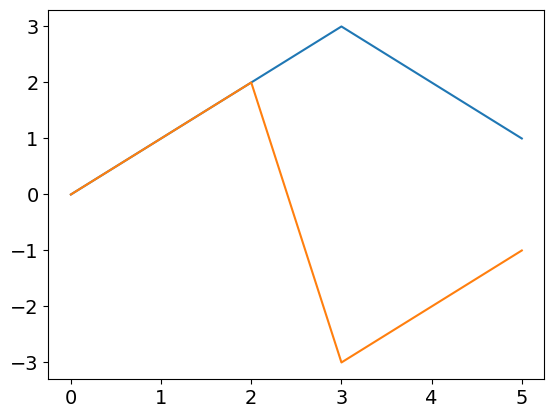

In [30]:
plt.plot(knrm)
plt.plot(kfreq)

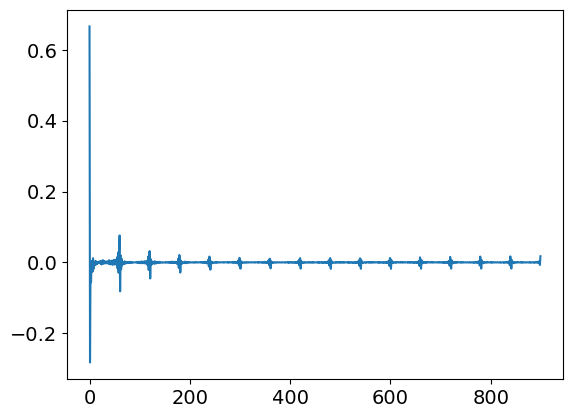

In [25]:
plt.plot(variance)

In [ ]:
# compute spectra
    
    ny, nx = u.shape

    if type(varray) == type(None):
        
        variance = 0.5*dct(dct(u, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2
        
    else:
        
        variance = 0.5*(dct(dct(u, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2 \
                       +dct(dct(v, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2)
           
    kfreq   = np.fft.fftfreq(nx) * nx
    kfreq2D = np.meshgrid(kfreq, kfreq)
    
    knrm   = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    knrm2  = 0.5*(knrm[1:,:] + knrm[:-1,:])
    knrm   = 0.5*(knrm2[:,1:] + knrm2[:,:-1])
    knrm   = knrm[:ny//2,:nx//2].flatten()
    
    # In order to make this similar to the DFT, you need to shift variances
    
    variance2 = np.zeros((ny,nx//2))
    variance3 = np.zeros((ny//2,nx//2))
    
    for i in np.arange(1,nx//2):   
        variance2[:,i-1] = variance[:,2*i-1] + variance[:,2*i]

    for j in np.arange(1,ny//2):   
        variance3[j-1,:] = variance2[2*j-1,:] + variance2[2*j,:]

    variance = variance3.flatten()
    
    kbins = np.arange(0.5, nx//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    PSbins, _, _ = stats.binned_statistic(knrm, variance, statistic = "mean", bins = kbins)
    
    PSbins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    waven = 2.*kvals / nx

CI_10min


FileNotFoundError: [Errno 2] No such file or directory: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min/balance.nc'

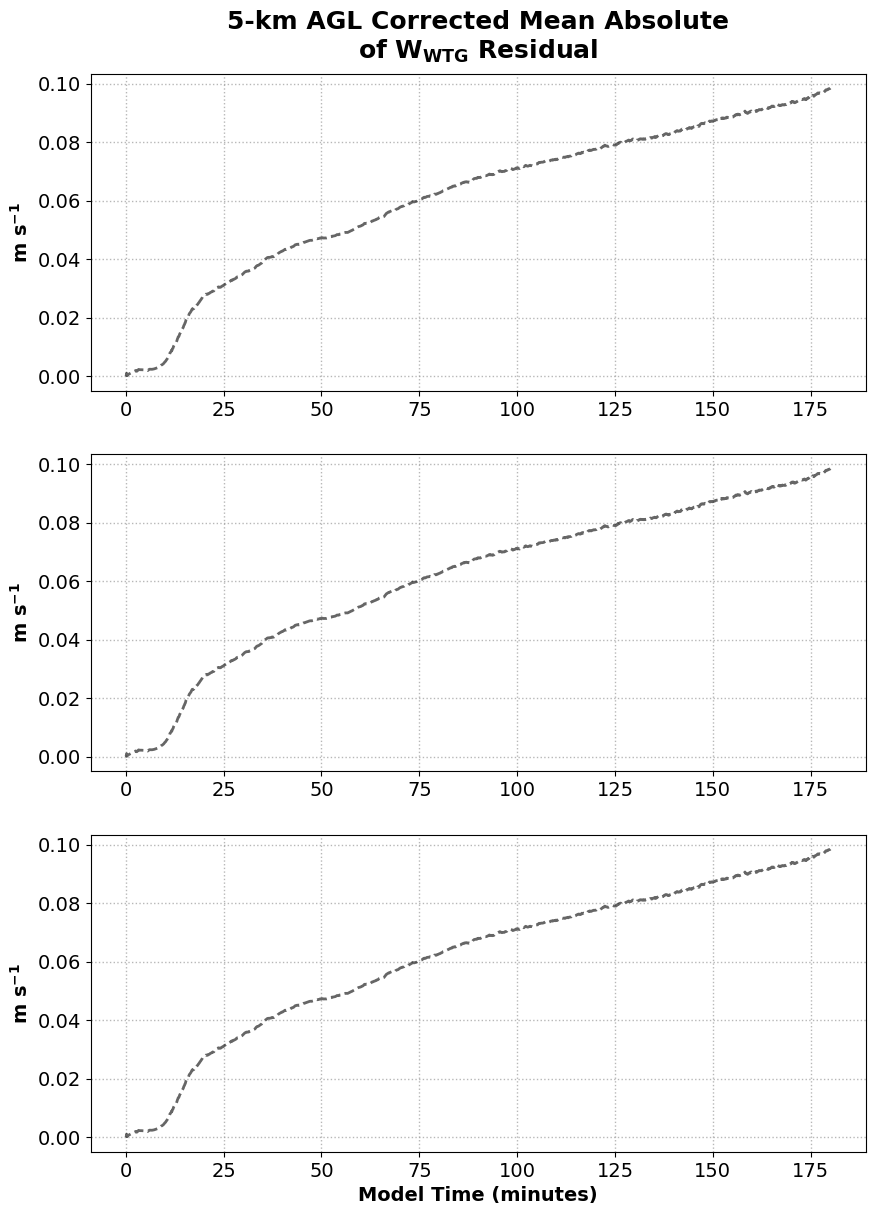

In [7]:
# weak tmperature gradient approx tests
# import scipy 


exps = ['CI_10min', 'CI_3min_adapt','CI_3min_R03','CI_3min' ]

exps = ['CI_10min','CI_10min_h9km','CI_3min','CI_3min_h9km','CI_3min_h9km_adapt'] #'CI_3min_adapt',

fcsts = ['FORECAST_20240508_2030','FORECAST_20240508_2100']
colors = cmaps.lipari(np.linspace(.25, .8, len(exps)))
colors = cmaps.pride(np.linspace(.25, .8, len(exps)))
markers = ['o', 's', 'D', 'H','^','o', 's', 'D', 'H','^']


fig,axes = plt.subplots(3,1, figsize=(10,14))#, sharex=True, sharey=True)

### WTG
control = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/balance.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values

for ax in axes:
    ax.plot(control.time, control.wres.mean(axis=1), color='k', label='Control', ls='--', lw=2, alpha=0.6)
    ax.grid(ls=':', alpha=0.7)
    ax.set_ylabel(r'm s$\mathbf{^{-1}}$');
    
axes[0].set_title("5-km AGL Corrected Mean Absolute\n"+r"of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
axes[2].set_xlabel('Model Time (minutes)')

for e,exp in enumerate(exps):
    print(exp)
    path = f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"

    wtg = xr.open_dataset(os.path.join(path, f'balance.nc' ))
    exper = open_exp(os.path.join(path))['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    fcst_len = wtg.time[-1]-wtg.time[0]
    
    i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120)+1
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]
    
    ti      = findnearest(control.time, wtg.time[0].values)
    tti     = findnearest(control.time, 180)
    wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)
    
    # find the peaks 
    df_final = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted}, index=time)
    df_final['wmax'] = df_final['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    axes[2].plot(df_final.wtg_adjusted,  color=colors[e], lw=1.5, alpha=0.7)

    scat=axes[2].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['wmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

    axes[2].text(0.98, 0.9, f'{fcst_len.values:.0f} min Forecast\nafter {dalen/60 :.0f} min DA', ha='right', va='center', fontsize=14, transform=axes[2].transAxes)
    
    
    for f,fcst in enumerate(fcsts):
        print(fcst)

        wtg = xr.open_dataset(os.path.join(path, fcst, f'balance.nc' ))
        exper, fcst_start = open_exp(os.path.join(path, fcst), fcst_start=True)
        freq = exper['DA_PARAMS']['assim_freq']
        #dalen =(dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds + wtg.time[0]*60
        da_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
        fcst_len = wtg.time[-1]-wtg.time[0]

        i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
        i1=findnearest(wtg.time.values, 120)+1
        wres = wtg['wres'].values[i0:]
        rain = wtg['qr'].values[i0:]
        time = wtg.time.values[i0:]

        ti      = findnearest(control.time, wtg.time[0].values)
        tti     = findnearest(control.time, 180)
        wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)

        # find the peaks 
        df = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted}, index=time)
        df['wmax'] = df['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    

        #### WTG
        axes[f].plot(df.wtg_adjusted,  color=colors[e], lw=1.5,alpha=0.7)
        i1 = findnearest(df_final.index.values, wtg.time[0].values)+1
        axes[f].plot(df_final.wtg_adjusted.iloc[:i1],  color=colors[e], lw=1.5,label=exp, alpha=0.7)

        scat=axes[f].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['wmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

        axes[f].text(0.98, 0.9, f'{fcst_len.values:.0f} min Forecast\nafter {int((fcst_start-da_start).seconds/60)} min DA', ha='right', va='center', fontsize=14, transform=axes[f].transAxes)
            
leg=axes[0].legend(fontsize=13, loc=2)
for line in leg.get_lines():
    line.set_linewidth(3.0)

axes[0].set_xlim(25, 180)
plt.subplots_adjust(hspace=0.05)

axes[0].set_xlim(25, 80)
axes[0].set_ylim(0., .3)


axes[1].set_xlim(60, 140)
axes[1].set_ylim(0., .6)


axes[2].set_xlim(90, 180)
axes[2].set_ylim(0., .85)

C15_5L18_R0
5400
FORECAST_20240508_2100
C10_5L18_R0
5400
FORECAST_20240508_2100
C3_5L18_R0
5400
FORECAST_20240508_2100


(0.0, 0.9)

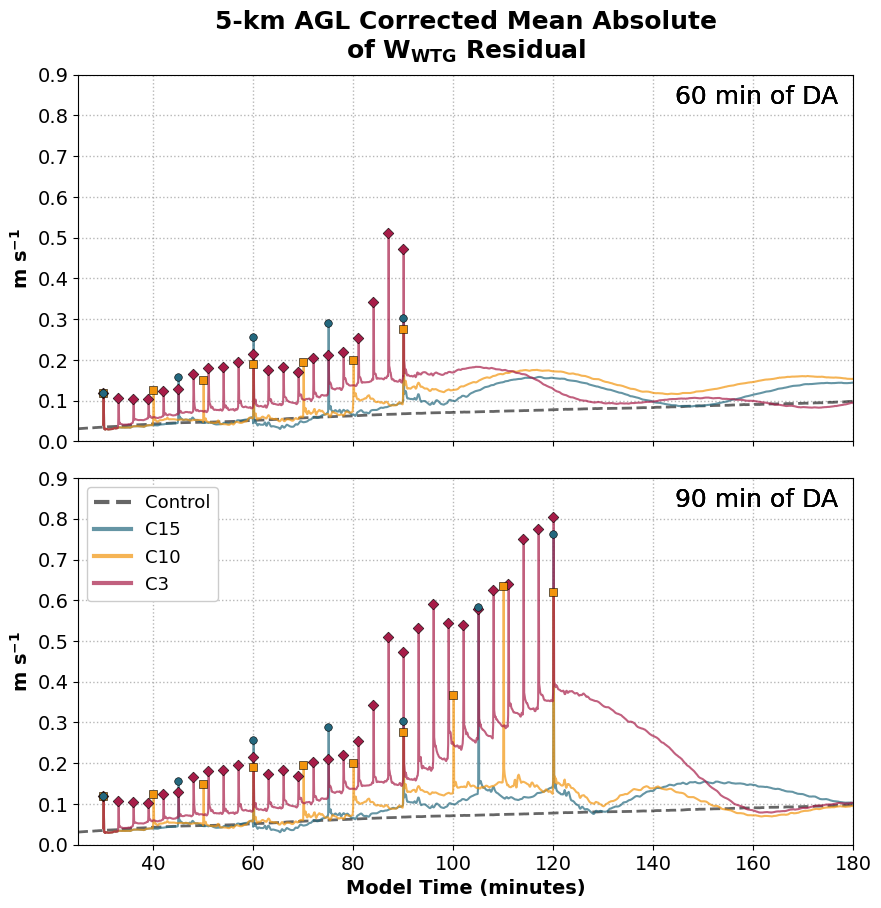

In [23]:
# weak tmperature gradient approx tests
# import scipy 




exps = [f'C{h}_5L18_R0' for h in [15,10,3]]

names = 'CI'


#exps = [f'C10_h{h:02d}_R0' for h in [7,9,12,15,18]]

fcsts = ['FORECAST_20240508_2100']
#colors = cmaps.lipari(np.linspace(.25, .8, len(exps)))
colors = cmaps.pride(.25, .8, len(exps))

if len(exps) == 3: colors = cmaps.pride([.2, .6, .8])


markers = ['o', 's', 'D', 'H','^','o', 's', 'D', 'H','^']


fig,axes = plt.subplots(2,1, figsize=(10,10), sharey=True, sharex=True)#, sharey=True)

### WTG
control = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/balance.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values

for ax in axes:
    ax.plot(control.time, control.wres.mean(axis=1), color='k', label='Control', ls='--', lw=2, alpha=0.6)
    ax.grid(ls=':', alpha=0.7)
    ax.set_ylabel(r'm s$\mathbf{^{-1}}$');
    
axes[0].set_title("5-km AGL Corrected Mean Absolute\n"+r"of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
axes[1].set_xlabel('Model Time (minutes)')

for e,exp in enumerate(exps):
    print(exp)
    path = f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"

    exp_name = rename(exp, version=names.upper())

    wtg = xr.open_dataset(os.path.join(path, f'balance.nc' ))
    exper = open_exp(os.path.join(path))['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    fcst_len = wtg.time[-1]-wtg.time[0]

    print(dalen)
    
    i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120)+1
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]

    fcst_len = time[-1]-time[0]
    
    ti      = findnearest(control.time, wtg.time[0].values)
    tti     = findnearest(control.time, 180)
    wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)
    
    # find the peaks 
    df_final = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted}, index=time)
    df_final['wmax'] = df_final['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    axes[1].plot(df_final.wtg_adjusted,  color=colors[e], lw=1.5, alpha=0.7,label=exp_name)

    scat=axes[1].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['wmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

    #axes[1].text(0.98, 0.9, f'{60} min Forecast\nafter {dalen/60 :.0f} min DA', ha='right', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].text(0.98, 0.94, f'{dalen/60 :.0f} min of DA', ha='right', va='center', fontsize=18, transform=axes[1].transAxes)
    
    for f,fcst in enumerate(fcsts):
        print(fcst)

        try:

            wtg = xr.open_dataset(os.path.join(path, fcst, f'balance.nc' ))
            exper, fcst_start = open_exp(os.path.join(path, fcst), fcst_start=True)
            freq = exper['DA_PARAMS']['assim_freq']
            #dalen =(dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds + wtg.time[0]*60
            da_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
            fcst_len = wtg.time[-1]-wtg.time[0]
    
            i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
            i1=findnearest(wtg.time.values, 120)+1
            wres = wtg['wres'].values[i0:]
            rain = wtg['qr'].values[i0:]
            time = wtg.time.values[i0:]
    
            ti      = findnearest(control.time, wtg.time[0].values)
            tti     = findnearest(control.time, 180)
            wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)
    
            # find the peaks 
            df = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted}, index=time)
            df['wmax'] = df['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
        
    
            #### WTG
            axes[f].plot(df.wtg_adjusted,  color=colors[e], lw=1.5,alpha=0.7)
            i1 = findnearest(df_final.index.values, wtg.time[0].values)+1
            axes[f].plot(df_final.wtg_adjusted.iloc[:i1],  color=colors[e], lw=1.5,label=exp_name, alpha=0.7)
    
            scat=axes[f].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['wmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)
    
            if f == 0:
                axes[f].text(0.98, 0.94, f'60 min of DA', ha='right', va='center', fontsize=18, transform=axes[f].transAxes)
                #axes[f].text(0.98, 0.9, f'{fcst_len.values:.0f} min Forecast\nafter {int((fcst_start-da_start).seconds/60)} min DA', ha='right', va='center', fontsize=14, transform=axes[f].transAxes)
        except: 
            print('nofcst')


# axn = axes[1].twinx()

# total_n = []

# for e,exp in enumerate(exps):
#     print(exp)
#     path = f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"
#     times, _, Nr,_,_ = get_counts(path, 'DBZ', inlier=False)
#     times, _, Nv,_,_ = get_counts(path, 'VR', inlier=False)
#     total_n.append(Nr+Nv)

# meanN = np.mean(total_n, axis=0)
# axn.scatter(times, meanN)
    
            
leg=axes[1].legend(fontsize=13, loc=2)
for line in leg.get_lines():
    line.set_linewidth(3.0)

axes[0].set_xlim(25, 180)
plt.subplots_adjust(hspace=0.1)

axes[0].set_ylim(0, 0.9)

C15_5L18_R0
FORECAST_20240508_2100
C10_5L18_R0
FORECAST_20240508_2100
C3_5L18_R0
FORECAST_20240508_2100


(0.0, 0.088)

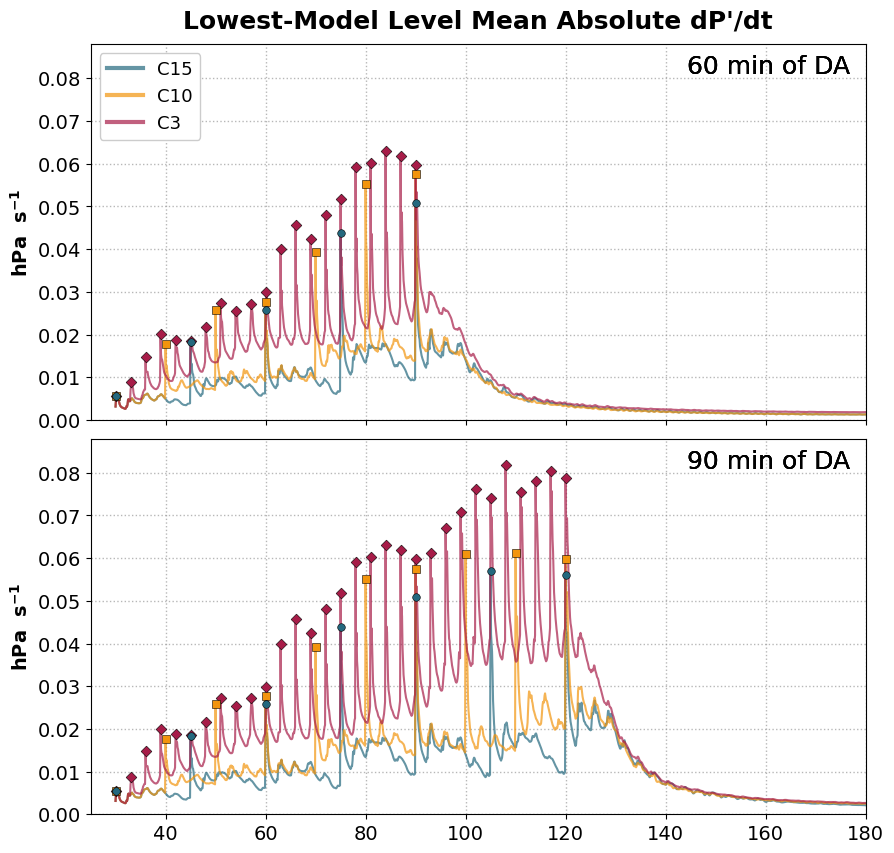

In [24]:
exps = [f'C10_h{h:02d}_R0' for h in [7,9,12,15,18]]

exps = [f'C3_5L{h:02d}_R0' for h in [7,9,12]]+[f'C3_3L{h:02d}_R0' for h in [7,9,12]]

exps = [f'C3_5L{h:02d}_R{r}' for h in [9,18] for r in [0,3,5]]

exps = [f'C{h}_5L18_R0' for h in [15,10,3]]

names = 'CI'

fcsts = ['FORECAST_20240508_2100']
colors = cmaps.lipari(np.linspace(.25, .8, len(exps)))
colors = cmaps.pride(np.linspace(.25, .8, len(exps)))
markers = ['o', 's', 'D', 'H','^','o', 's', 'D', 'H','^']


if len(exps) == 3: colors = cmaps.pride([.2, .6, .8])


fig,axes = plt.subplots(2,1, figsize=(10,10), sharey=True, sharex=True)#, sharey=True)

### WTG
control = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/balance.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)

for ax in axes:
    ax.grid(ls=':', alpha=0.7)
    ax.set_ylabel(r'hPa  s$\mathbf{^{-1}}$');
    
axes[0].set_title("Lowest-Model Level Mean Absolute dP\'/dt", weight='bold', y=1.02)
axes[1].set_ylabel(r'hPa  s$\mathbf{^{-1}}$');

for e,exp in enumerate(exps):
    print(exp)
    path = f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"
    exp_name = rename(exp, version=names.upper())

    wtg = xr.open_dataset(os.path.join(path, f'balance.nc' ))
    exper = open_exp(os.path.join(path))['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    fcst_len = wtg.time[-1]-wtg.time[0]
    
    i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120)+1
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]
    
    ti      = findnearest(control.time, wtg.time[0].values)
    tti     = findnearest(control.time, 180)
    #wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)
    pten = wtg.divc.values[i0:].mean(axis=1)/100
    
    # find the peaks 
    df_final = pd.DataFrame(data={ "pten":pten}, index=time)
    df_final['pmax'] = df_final['pten'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    #df_final['wmax'] = df_final['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()

    axes[1].plot(df_final.pten,  color=colors[e], lw=1.5, alpha=0.7)
    scat=axes[1].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['pmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

    #axes[1].text(0.98, 0.9, f'{60} min Forecast\nafter {dalen/60 :.0f} min DA', ha='right', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].text(0.98, 0.94, f'{dalen/60 :.0f} min of DA', ha='right', va='center', fontsize=18, transform=axes[1].transAxes)
    
    
    for f,fcst in enumerate(fcsts):
        print(fcst)

        wtg = xr.open_dataset(os.path.join(path, fcst, f'balance.nc' ))
        exper, fcst_start = open_exp(os.path.join(path, fcst), fcst_start=True)
        freq = exper['DA_PARAMS']['assim_freq']
        #dalen =(dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds + wtg.time[0]*60
        da_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
        fcst_len = wtg.time[-1]-wtg.time[0]

        i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
        i1=findnearest(wtg.time.values, 120)+1
        wres = wtg['wres'].values[i0:]
        rain = wtg['qr'].values[i0:]
        time = wtg.time.values[i0:]
        pten = wtg.divc.values[i0:].mean(axis=1)/100

        ti      = findnearest(control.time, wtg.time[0].values)
        tti     = findnearest(control.time, 180)
        #wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)

        # find the peaks 
        df = pd.DataFrame(data={ "pten":pten}, index=time)
        df['pmax'] = df['pten'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
       # df['wmax'] = df['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    

        #### WTG
        axes[f].plot(df.pten,  color=colors[e], lw=1.5,alpha=0.7)
        i1 = findnearest(df_final.index.values, wtg.time[0].values)+1
        axes[f].plot(df_final.pten.iloc[:i1],  color=colors[e], lw=1.5,label=exp_name, alpha=0.7)

        scat=axes[f].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['pmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

        #axes[f].text(0.98, 0.9, f'{fcst_len.values:.0f} min Forecast\nafter {int((fcst_start-da_start).seconds/60)} min DA', ha='right', va='center', fontsize=14, transform=axes[f].transAxes)
        axes[f].text(0.98, 0.94, f'60 min of DA', ha='right', va='center', fontsize=18, transform=axes[f].transAxes)
            
leg=axes[0].legend(fontsize=13, loc=2)
for line in leg.get_lines():
    line.set_linewidth(3.0)

axes[0].set_xlim(25, 180)
plt.subplots_adjust(hspace=0.05)

axes[0].set_ylim(0, .088)

CI_10min
FORECAST_20240508_2030
FORECAST_20240508_2100
CI_10min_h9km
FORECAST_20240508_2030
FORECAST_20240508_2100
CI_3min
FORECAST_20240508_2030
FORECAST_20240508_2100
CI_3min_adapt
FORECAST_20240508_2030
FORECAST_20240508_2100
CI_3min_h9km
FORECAST_20240508_2030
FORECAST_20240508_2100
CI_3min_h9km_adapt
FORECAST_20240508_2030
FORECAST_20240508_2100


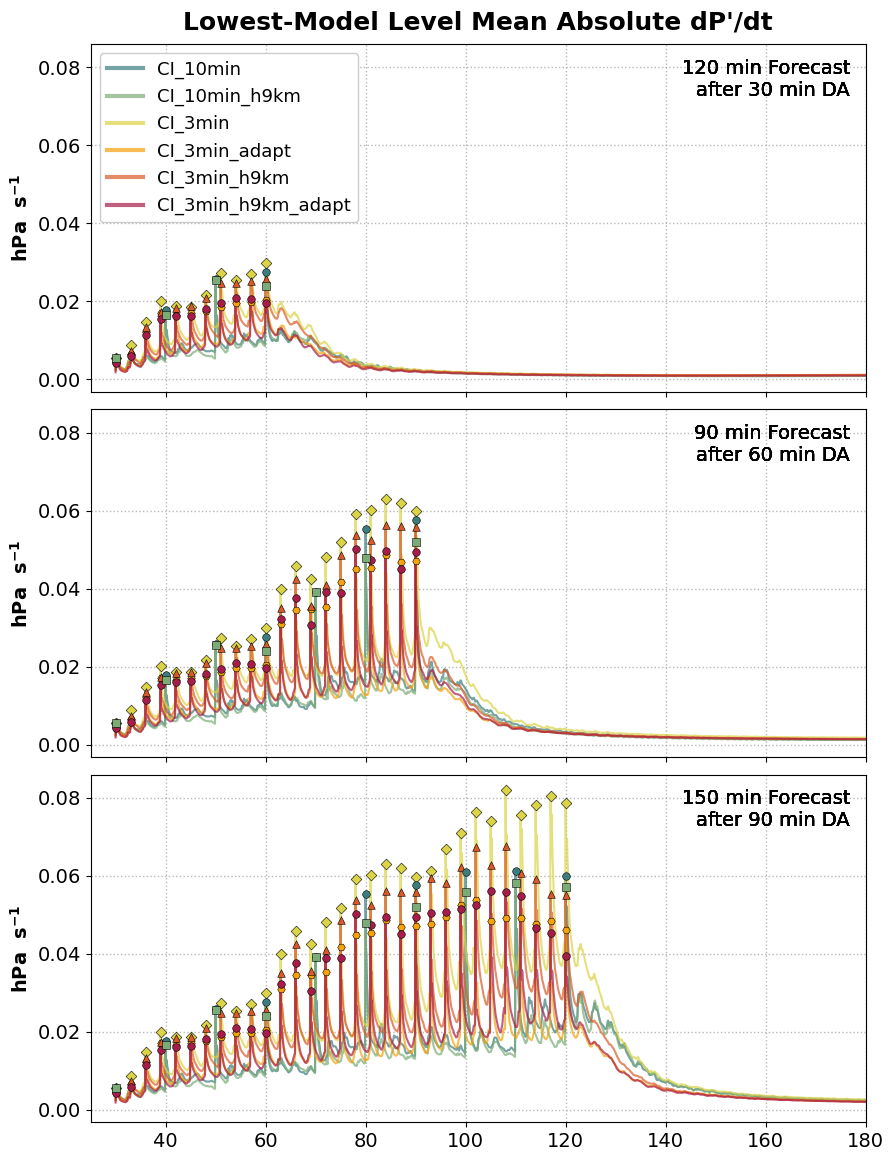

In [12]:
# weak tmperature gradient approx tests
# import scipy 


exps = ['CI_10min', 'CI_3min_adapt','CI_3min_R03','CI_3min' ]

exps = ['CI_10min','CI_10min_h9km','CI_3min','CI_3min_adapt','CI_3min_h9km','CI_3min_h9km_adapt']

fcsts = ['FORECAST_20240508_2030','FORECAST_20240508_2100']
colors = cmaps.lipari(np.linspace(.25, .8, len(exps)))
colors = cmaps.pride(np.linspace(.25, .8, len(exps)))
markers = ['o', 's', 'D', 'H','^','o', 's', 'D', 'H','^']


fig,axes = plt.subplots(3,1, figsize=(10,14), sharex=True, sharey=True)

### WTG
control = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/balance.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values

for ax in axes:
    #ax.plot(control.time, control.wres.mean(axis=1), color='k', label='Control', ls='--', lw=2, alpha=0.6)
    ax.grid(ls=':', alpha=0.7)
    ax.set_ylabel(r'hPa  s$\mathbf{^{-1}}$');
    
#axes[0].set_title("5-km AGL Corrected Mean Absolute\n"+r"of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
#axes[2].set_xlabel('Model Time (minutes)')


axes[0].set_title("Lowest-Model Level Mean Absolute dP\'/dt", weight='bold', y=1.02)
axes[1].set_ylabel(r'hPa  s$\mathbf{^{-1}}$');

for e,exp in enumerate(exps):
    print(exp)
    path = f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"

    wtg = xr.open_dataset(os.path.join(path, f'balance.nc' ))
    exper = open_exp(os.path.join(path))['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    fcst_len = wtg.time[-1]-wtg.time[0]
    
    i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120)+1
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]
    
    ti      = findnearest(control.time, wtg.time[0].values)
    tti     = findnearest(control.time, 180)
    wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)
    pten = wtg.divc.values[i0:].mean(axis=1)/100
    
    # find the peaks 
    df_final = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted, "pten":pten}, index=time)
    df_final['pmax'] = df_final['pten'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    df_final['wmax'] = df_final['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    axes[2].plot(df_final.pten,  color=colors[e], lw=1.5, alpha=0.7)

    scat=axes[2].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['pmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

    axes[2].text(0.98, 0.9, f'{fcst_len.values:.0f} min Forecast\nafter {dalen/60 :.0f} min DA', ha='right', va='center', fontsize=14, transform=axes[2].transAxes)
    
    
    for f,fcst in enumerate(fcsts):
        print(fcst)

        wtg = xr.open_dataset(os.path.join(path, fcst, f'balance.nc' ))
        exper, fcst_start = open_exp(os.path.join(path, fcst), fcst_start=True)
        freq = exper['DA_PARAMS']['assim_freq']
        #dalen =(dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds + wtg.time[0]*60
        da_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
        fcst_len = wtg.time[-1]-wtg.time[0]

        i0=findnearest(wtg.time.values, np.max([30,wtg.time[0].values])) # this will be zero if you used a "pre cooked" set up
        i1=findnearest(wtg.time.values, 120)+1
        wres = wtg['wres'].values[i0:]
        rain = wtg['qr'].values[i0:]
        time = wtg.time.values[i0:]
        pten = wtg.divc.values[i0:].mean(axis=1)/100

        ti      = findnearest(control.time, wtg.time[0].values)
        tti     = findnearest(control.time, 180)
        wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)

        # find the peaks 
        df = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted, "pten":pten}, index=time)
        df['pmax'] = df['pten'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
        df['wmax'] = df['wtg_adjusted'].rolling(window=int(6*freq/60), center=True, min_periods=int(6*freq/60/2)).max()
    

        #### WTG
        axes[f].plot(df.pten,  color=colors[e], lw=1.5,alpha=0.7)
        i1 = findnearest(df_final.index.values, wtg.time[0].values)+1
        axes[f].plot(df_final.pten.iloc[:i1],  color=colors[e], lw=1.5,label=exp, alpha=0.7)

        scat=axes[f].scatter(df_final.index.values[:i1][::int(freq/6)], df_final['pmax'].values[:i1][::int(freq/6)], color=colors[e], s=30,marker=markers[e], zorder=200+freq, ec='k', linewidth=0.4)

        axes[f].text(0.98, 0.9, f'{fcst_len.values:.0f} min Forecast\nafter {int((fcst_start-da_start).seconds/60)} min DA', ha='right', va='center', fontsize=14, transform=axes[f].transAxes)
            
leg=axes[0].legend(fontsize=13, loc=2)
for line in leg.get_lines():
    line.set_linewidth(3.0)

axes[0].set_xlim(25, 180)
plt.subplots_adjust(hspace=0.05)

In [19]:
len(rain)

1801

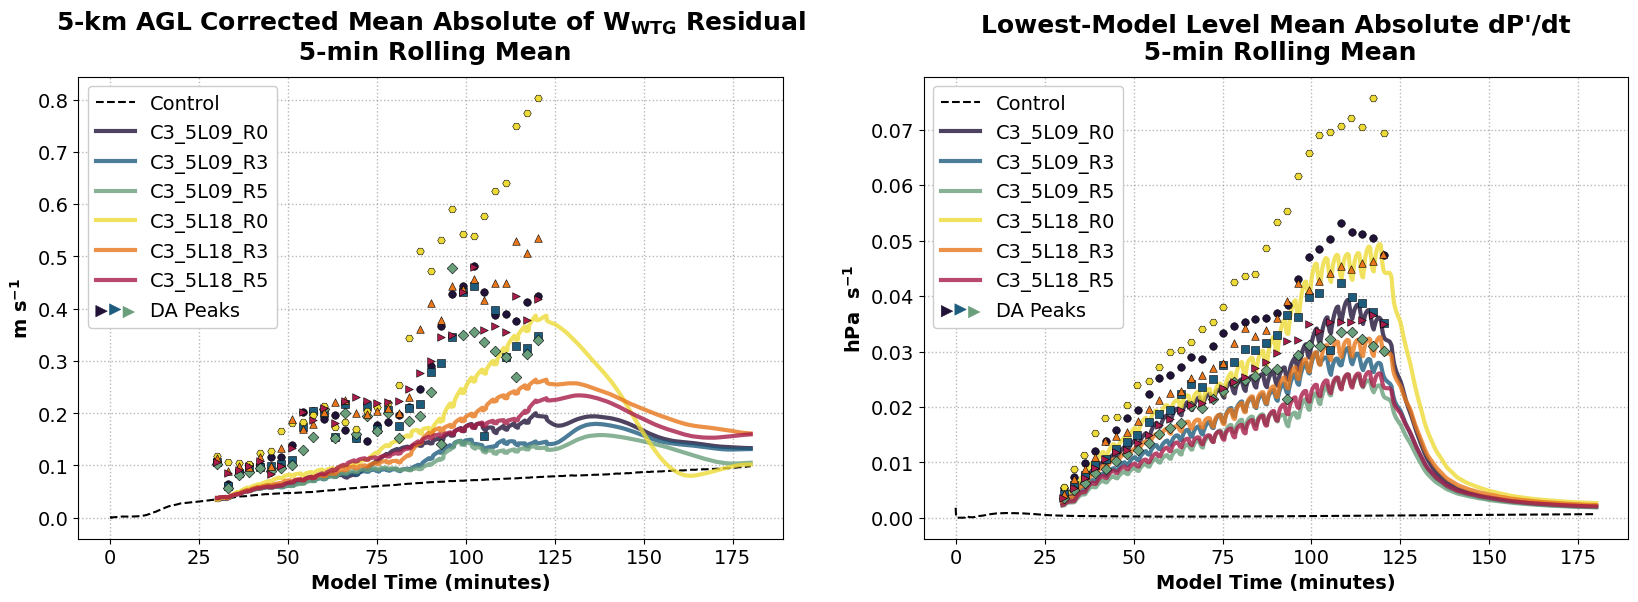

In [11]:
##################

# exps = ['CI_10min','CI_3min_DBZ0inlier', 'CI_3min',]
# exps = ['CI_10min','CI_3min_loc2','CI_3min_RTPP_05_loc2','CI_3min_60','CI_3min_60_RTPP05']
# exps = ['CI_10min','CI_10min_loc2', 'CI_3min', 'CI_3min_loc2']

# exps = [ 'CI_3min_loc2','CI_3min_RTPP_05_loc2', 'CI_3min_60','CI_3min_60_RTPP05']



members = np.arange(0, 36, 1)
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
#colors = cmaps.lipari(np.linspace(.28, .8, len(exps)))
fig,axes = plt.subplots(1,2, figsize=(20, 6))

#colors = cmaps.pride(np.linspace(.2, .8, len(exps)))

exps = ['CI_10min','CI_3min','CI_3min_R01', 'CI_3min_R03', 'CI_3min_R05','CI_3min_R07', 'CI_3min_R09']

exps = [f'C3_5L{h:02d}_R{r}' for h in [9,18] for r in [0,3,5]]

#exps = ['CI_10min','CI_3min','CI_3min_R03', 'CI_3min_R05',]

colors = cmaps.pride(np.linspace(.02, .8, len(exps)))
#colors = cmaps.pride(np.linspace(.2, .8, len(exps)))

markers = ['o', 's', 'D', 'H','^', '>', '<']
###### control run

control = xr.open_dataset(f'{fpath}Control/balance.nc')

ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values

axes[0].plot(control.time, control.wres.mean(axis=1), color='k', label='Control', ls='--')
axes[1].plot(control.time, control['divc'].values.mean(axis=1)/100, color='k', label='Control', ls='--')

## need if plotting 60 members
# control60 = xr.open_dataset(f'{fpath}Control_60/balance.nc')
# ti      = findnearest(control60.time, 30)
# tti     = findnearest(control60.time, 180)
# slope60, _,_,_,_= scipy.stats.linregress(control60['wres'][ti:,:].values.ravel(), control60['qr'][ti:,:].values.ravel())
# control_rain60 = control60['qr'].values
# axes[0].plot(control60.time, control60.wres.mean(axis=1), color='gray', label='Control_60', ls='--')


####### add experiments

for i,exp in enumerate(exps): 

    # get da times
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)['DA_PARAMS']
    freq = exper['assim_freq']
    dalen =(dt.datetime.strptime(exper['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    peaks = (np.arange(0,dalen+freq/2, freq )/6).astype(int) +1

    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
    wres = wtg['wres'].values[i0:]
    rain = wtg['qr'].values[i0:]
    time = wtg.time.values[i0:]
    pten = wtg.divc.values[i0:].mean(axis=1)/100

    if np.shape(rain)[1]  >36:
        wtg_adjusted = (wres- (1/slope60)*(rain - control_rain60[ti:ti+len(rain)])).mean(axis=1)
    else:
        wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)])).mean(axis=1)

    df = pd.DataFrame(data={"wtg_adjusted":wtg_adjusted, "pten":pten}, index=time)
    df['rolled'] = df['wtg_adjusted'].rolling(window=50, center=True, min_periods=5).mean()
    df['rolled_p'] = df['pten'].rolling(window=50, center=True, min_periods=5).mean()
    

    #### WTD
    peak_locs = []
    for p in peaks:
        peak_locs.append(df.wtg_adjusted.iloc[p:p+6].argmax()+p)
    #scat=axes[0].scatter(df.index.values[peak_locs], df.wtg_adjusted.values[peak_locs], color=colors[i], s=30,marker='d')
    scat=axes[0].scatter(df.index.values[peak_locs], df.wtg_adjusted.values[peak_locs], color=colors[i], s=30,marker=markers[i], zorder=200+freq, ec='k', linewidth=0.4)
    axes[0].plot(df.rolled,  color=colors[i], lw=3,label=exp, alpha=0.8)


    #### PRESSURE TENDENCY
    peak_locs = []
    for p in peaks:
        peak_locs.append(df.pten.iloc[p:p+6].argmax()+p)
    #scat=axes[1].scatter(df.index.values[peak_locs], df.pten.values[peak_locs], color=colors[i], s=30,marker='d')
    scat=axes[1].scatter(df.index.values[peak_locs], df.pten.values[peak_locs], color=colors[i], s=30,marker=markers[i], zorder=200+freq, ec='k', linewidth=0.4)
    axes[1].plot(df.rolled_p,  color=colors[i], lw=3,label=exp, alpha=0.8)

    
axes[0].set_title("5-km AGL Corrected Mean Absolute of W$\mathbf{_{WTG}}$ Residual"+"\n 5-min Rolling Mean", weight='bold', y=1.02)
axes[0].set_xlabel('Model Time (minutes)')
axes[0].set_ylabel(r'm s$\mathbf{^{-1}}$');

axes[1].set_title("Lowest-Model Level Mean Absolute dP\'/dt\n 5-min Rolling Mean", weight='bold', y=1.02)
axes[1].set_xlabel('Model Time (minutes)')
axes[1].set_ylabel(r'hPa  s$\mathbf{^{-1}}$');


for ax in axes:

    ax.grid(ls=':', alpha=0.7)

    handles, labels =ax.get_legend_handles_labels()
    n = len(labels)
    
    handles.append(scat)
    labels.append('DA Peaks')
    
    scatterpoints=np.clip(len(exps), 1, 3)
    
    leg=ax.legend(handles, labels, fontsize=14, scatterpoints=scatterpoints, markerscale=1.5, loc=2)
    leg.legend_handles[n].set_facecolors(colors)
    leg.legend_handles[n].set_edgecolors(colors)


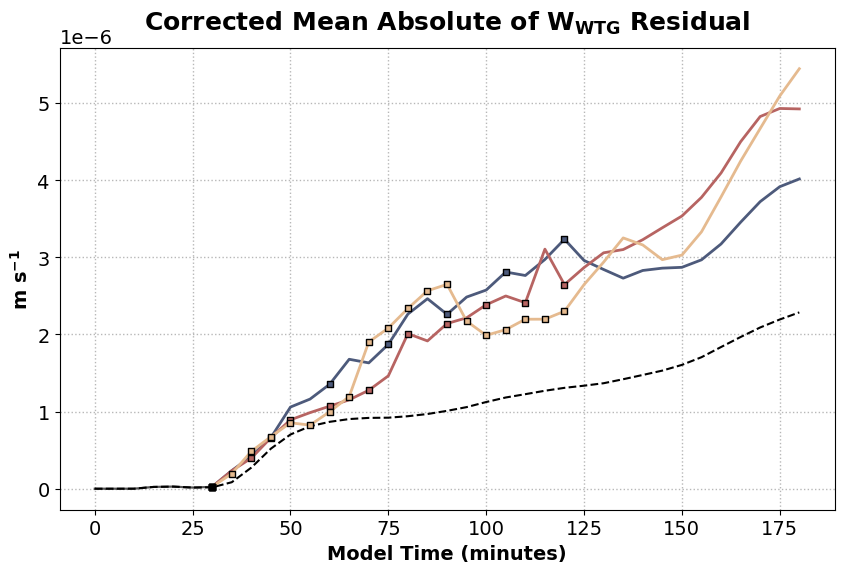

In [31]:
# weak tmperature gradient approx tests
# import scipy 



fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
exps = ['CI_15min','CI_10min','CI_5min']
labels = [ '15 min CI', '10 min CI', '5 min CI']

colors = cmaps.lipari(np.linspace(.24, .85, len(exps)))

#vary = 'rain_accum_5min_mean'
vary = 'qr'



fig,ax = plt.subplots(figsize=(10, 6))

control = xr.open_dataset(f'{fpath}Control/WTD.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 120)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][:,ti:].values.ravel(), control[vary][:,ti:].values.ravel())
control_rain = control[vary].values

ax.plot(control.time, control.qr.mean(axis=0), color='k', label='Control', ls='--')

for i,exp in enumerate(exps): 
    wtd = xr.open_dataset(f'{fpath}{exp}/WTD.nc')

    wres = wtd['wres'].values
    rain = wtd[vary].values.mean(axis=0)
    wtd_adjusted = (wres).mean(axis=0)# - (1/slope)*(rain - control_rain)).mean(axis=0)

    #ax.plot(wtd.time[ti:], wtd_adjusted[ti:], color=colors[i], lw=2, label=labels[i], alpha=0.5)

    wtd_adjusted = (wres- (1/slope)*(rain - control_rain)).mean(axis=0)

    ax.plot(wtd.time[ti:], rain[ti:], color=colors[i], lw=2, label=labels[i])
    
    ax.scatter(np.arange(30, 121, 5*(len(exps)-i)),  rain[ti:tti+1][::(3-i)], color=colors[i], marker='s', s=15, edgecolor='k', zorder=20, label=f'Time of DA')

    ax.plot(wtd.time[:ti+1], wtd['qr'][:,:ti+1].mean(axis=0), color='k', alpha=0.3)
    ax.scatter(wtd.time[ti], wtd['qr'][:,ti].mean(axis=0),color='k', marker='s', s=15, edgecolor='k', zorder=20)

ax.set_title(r"Corrected Mean Absolute of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
ax.set_xlabel('Model Time (minutes)')
ax.set_ylabel(r'm s$\mathbf{^{-1}}$');

ax.grid(ls=':', alpha=0.7)

# handles, labels =ax.get_legend_handles_labels()
# new_handles,new_labels = [handles[0],handles[1],handles[3],handles[5], (handles[2])], [labels[0], labels[1],labels[3], labels[5], labels[2]]
# leg=ax.legend(new_handles, new_labels, fontsize=14, scatterpoints=3, markerscale=1.5)
# leg.legend_handles[4].set_facecolors(colors)


In [5]:
PRIOR =False
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C3_5L18_R0/'

time = dt.datetime(2024,5,8,21,30)

with open(f'{fpath}letkf.exp', 'rb') as f:exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
ens.ens_CM1_coords(ens_state)

NameError: name 'ens' is not defined

<xarray.DataArray ()> Size: 8B
array(0.5266186)
Coordinates:
    t        int64 8B 0
    nk       int64 8B 16
<xarray.DataArray ()> Size: 8B
array(0.34753641)
Coordinates:
    t        int64 8B 0
    nk       int64 8B 16


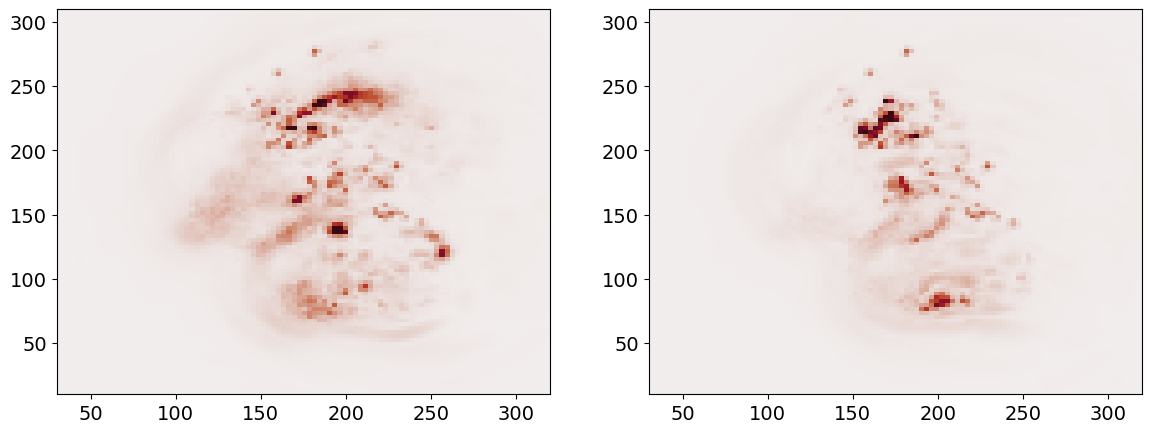

In [70]:

control_nc = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/full_ens_fcst.nc')
control = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/balance.nc')
ti      = findnearest(control.time, 30)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
mytime     = findnearest(control.time, 120)
control_rain = control_nc['qr'].values[0, :-1, findnearest(control_nc.z, 5)]


exp = 'C3_5L18_R0'

exps = [f'C3_5L{h:02d}_R0' for h in [9,18]]#,9,12,15,

fig, axes=plt.subplots(1,len(exps), figsize=(14, 5))

for e,exp in enumerate(exps[::-1]):
    fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc")[0]
    cm1 = xr.open_dataset(fpath, decode_timedelta=True)
    
    th0 = cm1.th[0,:-1, :, :, :].mean(axis=(2,3)) # mean profile for all ens members
    dth0dz = np.gradient(th0, axis=1)/np.gradient(cm1.z*1000)
    w_wtg = (cm1.tte[0, :-1,:]/dth0dz[:,:,np.newaxis, np.newaxis])[:,height]
    w_res = cm1.w[0,:-1, height] - w_wtg
    w_res_corr = abs(w_res -(1/slope)*( cm1.qr[0,:-1, height] - control_rain))

    axes[e].pcolormesh(cm1.xh, cm1.yh, w_res_corr.mean(axis=0), cmap=cmaps.amp, vmin=0, vmax=20)
    print(np.mean(w_res_corr))
#plt.colorbar()
    axes[e].set_xlim(50-20,300+20)
    axes[e].set_ylim(30-20,290+20)

In [40]:
np.shape(control_rain)

(37, 52, 128, 128)

In [38]:
control_nc.time.values

array(['2024-05-08T21:30:00.000000000', '2024-05-08T21:45:00.000000000',
       '2024-05-08T22:00:00.000000000', '2024-05-08T22:15:00.000000000',
       '2024-05-08T22:30:00.000000000'], dtype='datetime64[ns]')

In [47]:
w_res_corr = abs(w_res -(1/slope)*( cm1.qr[0,:-1, height] - control_rain))

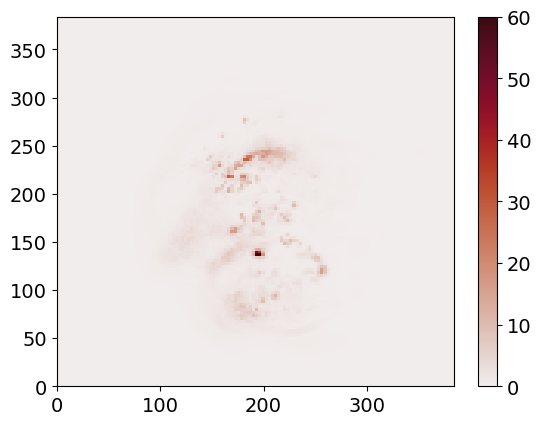

In [56]:
plt.pcolormesh(cm1.xh, cm1.yh, w_res_corr.mean(axis=0), cmap=cmaps.amp, vmin=0, vmax=60)
plt.colorbar()

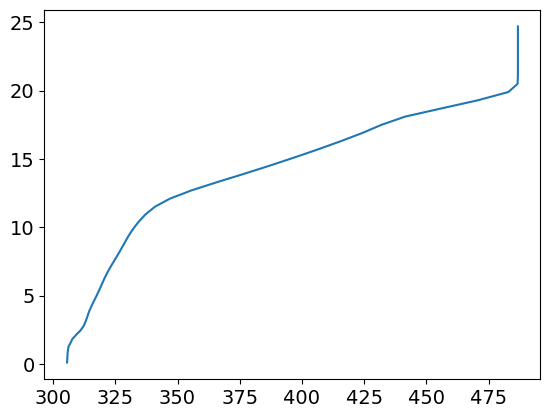

In [16]:
plt.plot(th0[0], cm1.z)

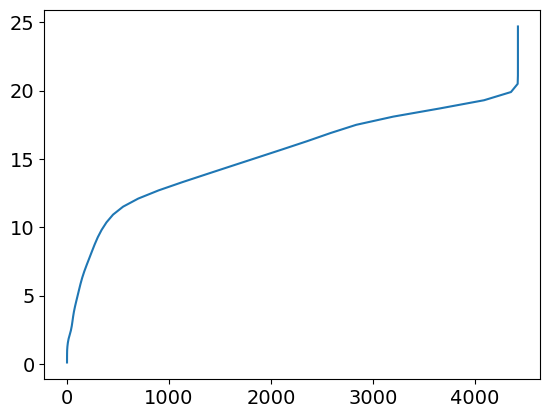

In [22]:
plt.plot(np.cumsum(dth0dz[0] * cm1.z*1000), cm1.z)

In [7]:
cm1.tte[0, :-1, height]

<xarray.DataArray 'tte' (ne: 37, nk: 52, nj: 128, ni: 128)> Size: 252MB
[31522816 values with dtype=float64]
Coordinates:
    t        int64 8B 0
  * ni       (ni) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nj       (nj) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nk       (nk) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
  * ne       (ne) int64 296B 0 1 2 3 4 5 6 7 8 9 ... 28 29 30 31 32 33 34 35 36

# eFFS stuff

In [4]:
from scipy import stats
exps = ['CI_10min', 'CI_3min', 'CI_3min_R09','CI_3min_R07', 'CI_3min_R05','CI_3min_R03', 'CI_3min_R01']
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))

# var = 'UH_2-5km'
mv = []
db = []
w = []

for i,exp in enumerate(exps):
    fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]
    fpath.extend(glob.glob(fpath[0]+'FORECAST*/'))

    for f in fpath:
        print(f)

        # pull in forecast data
        #try:
        cm1 = xr.open_dataset(f"{f}/full_ens_fcst.nc", decode_timedelta=True)
        times = [pd.to_datetime(t) for t in cm1.time.values]
        #ensN = cm1.sizes['ne']-1
       # mv.extend(cm1['UH_2-5km'][:,:-1].values.flatten())
        db.extend(cm1['dbz'][:,:-1, :].max(axis=2).values.flatten())
       # w.extend(cm1['w'][:,:-1,findnearest(cm1.z, 2):findnearest(cm1.z, 5)+1].mean(axis=2).values.flatten())
        #except:
            #print('that one didnt work lol')

ds = xr.open_dataset('/work/jessica.mcdonald/scratch_link/extra_NR_500m_may8/Processed_VerificationVars.nc')
ds = ds.rename({'UH2-5km':"UH_2-5km"})
times_NR = [pd.to_datetime(t) for t in ds.dates.values]


# print('UH: ensemble, nature run')   
# for val in [25, 50, 75, 100, 125, 150]:
#     perc = stats.percentileofscore(abs(np.array(mv)), val )
#     nrval = np.percentile(abs(ds['UH_2-5km'][30:].values), perc)
#     print(f'{val}, {nrval}')


print('dbz: ensemble, nature run')    
for val in [30, 35, 40, 45, 50]:
    perc = stats.percentileofscore(np.array(db), val )
    nrval=np.percentile(ds['dbz'][30:].values, perc)
    print(f'{val}, {nrval}')

# print('w')    
# for val in [3,4,5,6,7,8,9,10]:
#     perc = stats.percentileofscore(np.array(w), val )
#     nrval = np.percentile(ds['w'][30:,findnearest(cm1.z, 2):findnearest(cm1.z, 5)+1].mean(axis=1).values, perc)
#     print(f'{val}, {nrval}')

/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min/FORECAST_20240508_2100/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min/FORECAST_20240508_2030/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min/FORECAST_20240508_2030/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min/FORECAST_20240508_2100/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R09/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R09/FORECAST_20240508_2100/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R09/FORECAST_20240508_2030/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R07/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R07/FORECAST_20240508_2030/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R07/FORECAST_20240508_2100/
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R05/
/work/jessica.mcdo

In [3]:
#!/usr/bin/env python

from optparse import OptionParser
import sys
import netCDF4
import os
import numpy as np
from scipy import signal
import xarray as xr
import datetime as dt
import pandas as pd
import glob

import matplotlib.pyplot as plt

import skimage.measure as sm

sys.path.append('/work/jessica.mcdonald/CAM_analysis_tools/filter/')
import RaymondFilters

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

#-------------------------------------------------------------------------------
# Function for FFT convolution filter.

def fft_filter(binfld, winsize):

    n = int(winsize)
    conv = np.ones((n,n))

    fract = np.absolute(np.round(signal.fftconvolve(binfld, conv, mode='same'), 0)) / winsize**2.

    return fract

#-------------------------------------------------------------------------------
# Function for FFT convolution filter.

def fft_filter_ens(binfld, ne, winsize):

    n = int(winsize)
    conv = np.ones((2*ne,n,n))

    fract = np.amax(np.absolute(np.round(signal.fftconvolve(binfld, conv, mode='same'), 0)) / (ne*winsize**2.), axis=0)

    return fract

#-------------------------------------------------------------------------------
# Function to compute FSS using convolution via fast fourier transform (FFT).

def fourier_fss(fcst, obs, fthld, othld, winsize):

    pf = fft_filter(fcst >= fthld, winsize)
    po = fft_filter(obs >= othld, winsize)

    fbs = np.nanmean(np.power(pf - po, 2))
    fbsw = np.nanmean(np.power(pf, 2) + np.power(po, 2))

    fss = 1. - fbs/fbsw

    return fss, fbs, fbsw

#-------------------------------------------------------------------------------
# Function to compute eFSS using convolution via fast fourier transform (FFT).

def fourier_efss(fcst, obs, fthld, othld, ne, winsize):

    pf = fft_filter_ens(fcst >= fthld, ne, winsize)
    po = fft_filter(obs >= othld, winsize)

    fbs = np.nanmean(np.power(pf - po, 2))
    fbsw = np.nanmean(np.power(pf, 2) + np.power(po, 2))

    fss = 1. - fbs/fbsw

    return fss, fbs, fbsw


####################################### File Variables: ######################################################

# parser = OptionParser()
# parser.add_option("-d", dest="indir", type="string", default= None, help="input directory of summary files")
# parser.add_option("-m", dest="mrmsdir", type="string", default= None, help="input directory of mrms files")
# parser.add_option("-o", dest="outdir", type="string", help = "output directory")
# parser.add_option("-v", dest="var", type="string", help = "variable to process (e.g. uh2to5)")
# parser.add_option("-x", dest="xw", type="int", help = "x-dir starting point")
# parser.add_option("-y", dest="ys", type="int", help = "y-dir starting point")

# (options, args) = parser.parse_args()

# if ((options.indir == None) or (options.outdir == None) or (options.var == None) or (options.mrmsdir == None)):
#    print()
#    parser.print_help()
#    print()
#    sys.exit(1)
# else:
#    indir = options.indir
#    mrmsdir = options.mrmsdir
#    outdir = options.outdir
#    var = options.var


mrmsdir = '/work/jessica.mcdonald/scratch_link/extra_NR_500m_may8/'

var = 'compdz'

#################################### User-Defined Variables:  #####################################################

# Use percentile thresholds instead?
usepct = 0    # 1 for yes, 0 for no

# Bounds for subdomain if used

neighsize =[1.,3.,5.,9.,17.,33.,65.,129.,257.]  #[1.,7.,13.,25.,49.,97.,193.,385.,709.] #[1.,3.,5.,9.,17.,33.,65.,129.,257.]                 # neighborhood sizes

# Use neighborhoods that extend beyond domain boundaries?
usebdy = 1    # 1 for yes, 0 for no, currently not used

#################################### Set variable specific values:  #####################################################

if (var == 'compdz'):
    #mrms_var = 'refl_consv'
    #mrms_var = 'dz_consv'
    fcst_var = 'comp_dz'
    mrms_prct = [90.,95.,99.]
    fcst_prct = [90.,95.,99.]
    
    
    fcst_thds = [30.,35.,40.,45.,50.,55.]
    mrms_thds = [8. ,16.,24.,32.,40.,48.] # equivalent percentile value

elif (var == 'uh0to2'):
    mrms_var = 'azlo_cress'
    fcst_var = 'uh_0to2'
    mrms_prct = [99.5, 99.9, 99.95]
    fcst_prct = [99.5, 99.9, 99.95]
elif (var == 'uh2to5'):
    mrms_var = 'azmd_cress'
    fcst_var = 'uh_2to5'
    mrms_prct = [99.0, 99.9, 99.95]
    fcst_prct = [99.0, 99.9, 99.95]
   
    fcst_thds = [25, 50, 75, 100, 125, 150]
    mrms_thds = [46, 94, 141, 182, 226, 268] #quivalent percentile value
    
else:
   print("%s is an unsupported variable, please use 'compdz', 'uh0to2', or 'uh2to5'" %var)
   sys.exit(1)


ens2nr = {'UH_2-5km': {25: 46, 50: 94, 75: 141, 100: 182, 125: 226, 150: 268}, 
               'dbz': {30: 8, 35: 16, 40: 24, 45: 32, 50: 40, 55: 48}}

In [13]:
os.path.isfile(f'{indir}full_ens_fcst.nc')

False

In [4]:



usepct=0

exps = sorted([os.path.basename(g) for g in glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*L*_R*')])#[3:]

fpath=[]
for exp in exps:
    fpath.extend([f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"])
    fpath.extend(glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"+'FORECAST*/'))
    
for indir in fpath:
    
    
    
    
    for var in ['compdz', 'uh2to5']:
        

        tempname = f'fss_{var}.nc'
        out_file = os.path.join(indir, tempname)
        if (os.path.isfile(out_file) == False) &(os.path.isfile(f'{indir}full_ens_fcst.nc')==True):
            print(f'********************************** {var}')

            print('EXPERIMENT ', indir)
            
            print('VARIABLE ', var)            
            if (var == 'compdz'):
             
                mrms_prct = [90.,95.,99.]
                fcst_prct = [90.,95.,99.]
                fcst_thds = [30.,35.,40.,45.,50.,55.]
                mrms_thds = [30.,35.,40.,45.,50.,55.]
                #mrms_thds = [8. ,16.,24.,32.,40.,48.] # equivalent percentile value
            
            elif (var == 'uh0to2'):
     
                mrms_prct = [99.5, 99.9, 99.95]
                fcst_prct = [99.5, 99.9, 99.95]
    
            elif (var == 'uh2to5'):
     
                mrms_prct = [99.0, 99.9, 99.95]
                fcst_prct = [99.0, 99.9, 99.95]
                fcst_thds = [25, 50, 75, 100, 125, 150]
                mrms_thds = [46, 94, 141, 182, 226, 268] #quivalent percentile value
    
            elif (var == 'w2to5'):
                fcst_thds = [4,6,8,10,12]
                mrms_thds = [4,6,8,10,12] #equivalent percentile value
                
                
            else:
               print("%s is an unsupported variable, please use 'compdz', 'uh0to2', or 'uh2to5'" %var)
               sys.exit(1)
                
        
            #indir = fpath+exp # do forecasts tomorrow
            #indir = glob.glob(os.path.join(fpath,exp, 'FORECAST*'))[0] 
            
            
           ### read in nature run 
            NR_full = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc')
            
            NR_time = np.array([pd.to_datetime(t) for t in NR_full.dates.values])
            
            ### read in forecast
            fcst_full = xr.open_dataset(os.path.join(indir,'full_ens_fcst.nc'))
            fcst_time = [pd.to_datetime(t) for t in fcst_full.time.values]
            fcst_hr = [f.hour for f in fcst_time]
            fcst_min = [f.minute for f in fcst_time]
            nx, ny, nt, ne = fcst_full.sizes['ni'],fcst_full.sizes['nj'],fcst_full.sizes['t'],fcst_full.sizes['ne']-1
            dx,dy = np.gradient(fcst_full.xh).mean(),np.gradient(fcst_full.yh).mean()
            
            # # get proper times from nature run
            time_idx = [int(np.where(NR_time == t)[0][0]) for t in fcst_time]
            
            # now pull the variables you need
            if var == 'compdz':
                fcst = fcst_full['cdbz'][:, :-1]#.max(axis=2) # drop mean
                mrms = NR_full['cdbz'].values[time_idx]#.max(axis=1)
            
            if var == 'uh2to5':
                fcst = fcst_full['UH_2-5km'][:,:-1].values
                mrms = NR_full['UH2-5km'].values[time_idx]
    
            if var == 'w2to5':
                fcst = fcst_full['w_2-5km'][:,:-1].values
                mrms = NR_full['w_2-5km'].values[time_idx]
            
            
            ###################################### Computing eFSS #######################################################
            
            print("Computing eFSS")
            
            neighsize=[]
            
            if len(neighsize) == 0:
               minxy = min(nx, ny)
               for ii in range(1,minxy):
                  ns = ii**2
                  if ns % 2 == 0:
                     ns = ns - 1
                  if ns < minxy:
                     neighsize.append(ns)
            
            #neighsize=neighsize[0:5]
            
            # if nx == 300:
            #     print("\nUsing subdomain for 3KM.")
            #     usesub = 1
            
            
            #neighsize = np.asarray(neighsize)
            
            if usepct == 1:
               nft = len(fcst_prct)
               nmt = len(mrms_prct)
            else:
               nft = len(fcst_thds)
               nmt = len(mrms_thds)
            
            nnw = len(neighsize)
            
            fcst_thld = np.zeros((nt,nft))
            mrms_thld = np.zeros((nt,nmt))
            fcst_max = np.zeros((nt))
            mrms_max = np.zeros((nt))
            
            efbs = np.full((nt,nnw,nft),-999.)
            efbsr = np.full((nt,nnw,nft),-999.)
            efss = np.full((nt,nnw,nft),-999.)
            fssu = np.full((nt,nft),-999.)
            aefss = np.full((nt,nft),-999.)
            scales = np.zeros((nnw))
            po = np.full((nt,nft),0.0)
            pf = np.full((nt,nft),0.0)
            
            fbs = np.full((ne,nt,nnw,nft),-999.)
            fss = np.full((ne,nt,nnw,nft),-999.)
            fbsr = np.full((ne,nt,nnw,nft),-999.)
            afss = np.full((ne,nt,nft),-999.)
            
            for ii in range(0,nnw):
               print("\nWorking on neighborhood size of %s gridpoints..." %(neighsize[ii]))
               scales[ii] = (neighsize[ii] - 1.0)*dx/1000.
            
                   
            
               for jj in range(0,nft):
                  if usepct == 1:
                     print("Threshold: %s" %(fcst_prct[jj]))
                  # else:
                  #    print("MRMS Threshold: %s" %(mrms_thds[jj]))
                  #    print("FCST Threshold: %s" %(fcst_thds[jj]))
            
                  # Full domain
                  #if usesub == 0:
                      
                  for ts in range(0,nt):
                    if usepct == 1:
                       fcst_thld[ts,jj] = np.percentile(fcst[ts,:,:,:],fcst_prct[jj])
                       mrms_thld[ts,jj] = np.percentile(mrms[ts,:,:],mrms_prct[jj])
                    else:
                       fcst_thld[ts,jj] = fcst_thds[jj]
                       mrms_thld[ts,jj] = mrms_thds[jj]
                    
                    if ii == 0:
                       po[ts,jj] = 1.*np.count_nonzero(mrms[ts,:,:] >= mrms_thld[ts,jj])/np.count_nonzero(mrms[ts,:,:] >= 0.0)
                       pf[ts,jj] = 1.*np.count_nonzero(fcst[ts,:,:,:] >= fcst_thld[ts,jj])/np.count_nonzero(fcst[ts,:,:,:] >= 0.0)
                       fssu[ts,jj] = 0.5 + po[ts,jj]/2.
                       aefss[ts,jj] = (2.*po[ts,jj]*pf[ts,jj])/(np.power(po[ts,jj],2)+np.power(pf[ts,jj],2))
                    
                    if ((np.amax(fcst[ts,:,:,:]) >= fcst_thld[ts,jj]) or (np.amax(mrms[ts,:,:]) >= mrms_thld[ts,jj])):
                       efss[ts,ii,jj], efbs[ts,ii,jj], efbsr[ts,ii,jj] = fourier_efss(fcst[ts,:,:,:], mrms[ts,:,:], fcst_thld[ts,jj], mrms_thld[ts,jj], ne, neighsize[ii])
                    
                    if ii == 0 and jj == 0:
                       fcst_max[ts] = np.amax(fcst[ts,:,:,:])
                       mrms_max[ts] = np.amax(mrms[ts,:,:])
                    
                    # Compute FSS for each member
                    for em in range(0,ne):
                       if ii == 0:
                          ipo = 1.*np.count_nonzero(mrms[ts,:,:] >= mrms_thld[ts,jj])/np.count_nonzero(mrms[ts,:,:] >= 0.0)
                          ipf = 1.*np.count_nonzero(fcst[ts,em,:,:] >= fcst_thld[ts,jj])/np.count_nonzero(fcst[ts,em,:,:] >= 0.0)
                          afss[em,ts,jj] = (2.*ipo*ipf)/(np.power(ipo,2)+np.power(ipf,2))
                    
                       if ((np.amax(fcst[ts,em,:,:]) >= fcst_thld[ts,jj]) or (np.amax(mrms[ts,:,:]) >= mrms_thld[ts,jj])):
                          fss[em,ts,ii,jj], fbs[em,ts,ii,jj], fbsr[em,ts,ii,jj] = fourier_fss(fcst[ts,em,:,:], mrms[ts,:,:], fcst_thld[ts,jj], mrms_thld[ts,jj], neighsize[ii])
            
            ###################################### Output FSS: #######################################################
            
            tempname = f'fss_{var}.nc'
            out_file = os.path.join(indir, tempname)
            
            try:
               fout = netCDF4.Dataset(out_file, "w")
            except:
               print("Could not create %s!\n" % out_file)
            
            #fout = netCDF4.Dataset(out_file, "a")
            
            fout.createDimension('NE', ne) # number of ensemble members
            fout.createDimension('NT', nt) # n time steps 
            fout.createDimension('NW', nnw) # neightborhood window
            fout.createDimension('NTH', nft)  # length of percentile or threshold values 
            
            fout.createVariable('FCST_MAX_VALUE', 'f4', ('NT',))
            fout.createVariable('MRMS_MAX_VALUE', 'f4', ('NT',))
            ttt = fout.createVariable('TIME', np.float64, ('NT',))
            ttt.setncattr('unit', "seconds since 1970-01-01 00:00:00")
            fout.createVariable('HOUR', 'f4', ('NT',))
            fout.createVariable('MINUTE', 'f4', ('NT',))
            
            fout.createVariable('SCALES', 'f4', ('NW',))
            fout.createVariable('FCST_THLDS', 'f4', ('NT','NTH',))
            fout.createVariable('MRMS_THLDS', 'f4', ('NT','NTH',))
            fout.createVariable('FSSU', 'f4', ('NT','NTH',))
            fout.createVariable('EFSS', 'f4', ('NT','NW','NTH',))
            fout.createVariable('EFBS', 'f4', ('NT','NW','NTH',))
            fout.createVariable('EFBSR', 'f4', ('NT','NW','NTH',))
            fout.createVariable('AEFSS', 'f4', ('NT','NTH',))
            fout.createVariable('PO', 'f4', ('NT','NTH',))
            fout.createVariable('PF', 'f4', ('NT','NTH',))
            fout.createVariable('FSS', 'f4', ('NE','NT','NW','NTH',))
            fout.createVariable('FBS', 'f4', ('NE','NT','NW','NTH',))
            fout.createVariable('FBSR', 'f4', ('NE','NT','NW','NTH',))
            fout.createVariable('AFSS', 'f4', ('NE','NT','NTH',))
            
            fout.variables['TIME'][:] = [netCDF4.date2num(t,"seconds since 1970-01-01 00:00:00") for t in fcst_time]
            fout.variables['HOUR'][:] = fcst_hr[:]
            fout.variables['MINUTE'][:] = fcst_min[:]
            fout.variables['SCALES'][:] = scales
            fout.variables['FCST_THLDS'][:,:] = fcst_thld # percentile values or thresholds 
            fout.variables['MRMS_THLDS'][:,:] = mrms_thld # percentile values or thresholds 
            fout.variables['FCST_MAX_VALUE'][:] = fcst_max
            fout.variables['MRMS_MAX_VALUE'][:] = mrms_max
            fout.variables['FSSU'][:,:] = fssu  #FSS uniform, which is halfway between a random forecast and perfect skill ("target skill")
            fout.variables['EFSS'][:,:,:] = efss # ensemble FSS, neighborhood probabilities extend into ensemble space
            fout.variables['EFBS'][:,:,:] = efbs # "MSE for the observed and forecast fractions from a neighborhood length of n"
            fout.variables['EFBSR'][:,:,:] = efbsr # reference MSE, "largest possible MSE that can be obtained from the forecast and observed fractions"
            fout.variables['AEFSS'][:,:] = aefss  # asymptotic eFSS
            fout.variables['PO'][:,:] = po  # observed frequency f0 of the observations 
            fout.variables['PF'][:,:] = pf  # observed frequency of the forecasts
            fout.variables['FSS'][:,:,:,:] = fss # fraction skill score
            fout.variables['FBS'][:,:,:,:] = fbs
            fout.variables['FBSR'][:,:,:,:] = fbsr
            fout.variables['AFSS'][:,:,:] = afss #asymptotic FSS
            
            fout.close()
            del fout

        else:
            print(indir, ' file already made')


/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0/FORECAST_20240508_2100/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0/FORECAST_20240508_2100/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L09_R0/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L09_R0/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L09_R0/FORECAST_20240508_2100/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L09_R0/FORECAST_20240508_2100/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L12_R0/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L12_R0/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L12_R0/FORECAST_20240508_2100/  f

In [15]:
os.path.isfile('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C10_3L07_R0/FORECAST_20240508_2100/fss_uh2to5.nc')

False

In [19]:
import colormaps as cmaps

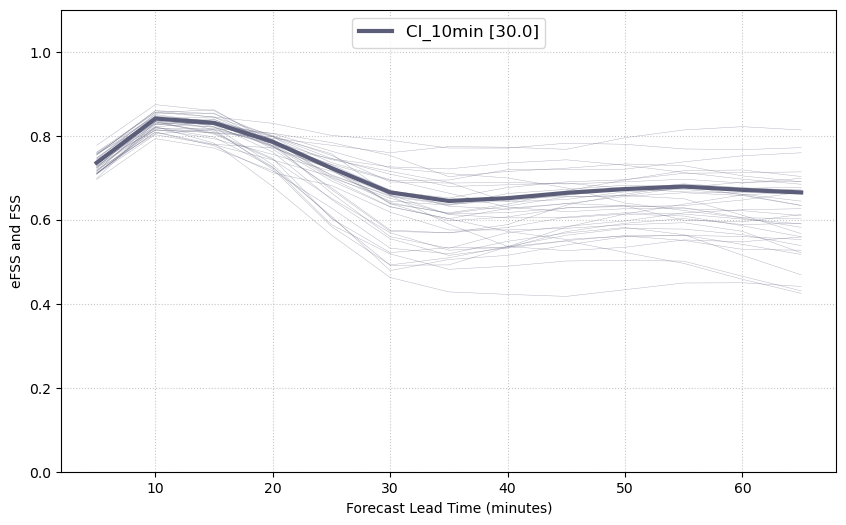

In [23]:
#### add forecast start time to the plot title

exps = ['CI_10min']
fig, ax = plt.subplots(1,1, figsize=(10, 6))
colors = cmaps.lipari(np.linspace(.28, .8, len(exps)))
#colors = cmaps.pride(np.linspace(.2, .8, len(exps)+1))
for i, exp in enumerate(exps):

    ds = xr.open_dataset(glob.glob(os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, 'fss_compdz.nc'))[0])
    #prct = [90.,95.,99.]
        
    tarr = netCDF4.num2date( ds.TIME.values, ds.TIME.unit)
    fcst_lead = np.array([(t - tarr[0]).seconds for t in tarr]) # the time step is the amount that the start is off by (I don't inlcude the analysis)
    fcst_lead =(fcst_lead)/60

    neighborhoods = ds.SCALES.values*1000


    threshold_level   = 30 # dbz
    neighborhood_size = 24 # km [  0.,   6.,  24.,  42.,  72., 102., 144., 186., 240., 294., 360.]
    #fcst_leadtime     = 60 # minutes
    
    th_i = findnearest(ds.FCST_THLDS[0].values, threshold_level)
    n_i  = findnearest(neighborhoods, neighborhood_size)
    #t_i  = findnearest(fcst_lead, fcst_leadtime)

    fstart = (tarr[0] - dt.timedelta(minutes=fcst_lead[0])).strftime('%H:%M UTC')
    #fstart =tarr[0].strftime('%H:%M UTC')
    
    
    #ax.set_title(f'Composite Model Reflectivity, p{prct[th_i]} [{np.mean(ds.MRMS_THLDS.values[:,th_i]):.1f}], {neighborhood_size} km width\n Forecast Start {fstart}', weight='bold')
    ax.set_ylim(0,1.1)
    ax.plot(fcst_lead,ds.FSS[:,:,n_i, th_i].T, alpha=0.5, lw=0.3,color=colors[i]);
    ax.plot(fcst_lead,ds.EFSS[:,n_i, th_i],color=colors[i], lw=3, alpha=1,label=f'{exp} [{np.mean(ds.FCST_THLDS.values[:,th_i]):.1f}]');
    ax.legend(fontsize=12, ncol=3, loc='upper center')
    ax.grid(ls=':', alpha=0.7)
    ax.set_xlabel('Forecast Lead Time (minutes)')
    ax.set_ylabel('eFSS and FSS')



# for th_i in [0,1,2]:
#     fig, ax = plt.subplots(1,1, figsize=(10, 6))
#     for i, exp in enumerate(exps):
    
#         #ds = xr.open_dataset(glob.glob(os.path.join(fpath,exp, 'FORECAST*','fss_uh2to5.nc'))[0])
#         ds = xr.open_dataset(glob.glob(os.path.join(fpath,exp,'fss_uh2to5.nc'))[0])
#         prct = [99.0, 99.9, 99.95]
        
#         tarr = netCDF4.num2date( ds.TIME.values, ds.TIME.unit)
#         fcst_lead = np.array([(t - tarr[0]).seconds for t in tarr]) # the time step is the amount that the start is off by (I don't inlcude the analysis)
#         fcst_lead =(fcst_lead+fcst_lead[1])/60
    
#         neighborhoods = ds.SCALES.values*1000
    
    
#         #threshold_level   = 2#264 # m2/s2 28.,264.,374.,400.
#         neighborhood_size = 24 # km [  0.,   6.,  24.,  42.,  72., 102., 144., 186., 240., 294., 360.]
#         #fcst_leadtime     = 60 # minutes
        
#         #th_i = 0    #findnearest(ds.FCST_THLDS[0].values, threshold_level)
#         n_i  = findnearest(neighborhoods, neighborhood_size)
#         #t_i  = findnearest(fcst_lead, fcst_leadtime)
        
        
        
#         fstart = (tarr[0] - dt.timedelta(minutes=fcst_lead[0])).strftime('%H:%M UTC')
#         #fstart =tarr[0].strftime('%H:%M UTC')
    
#         print(np.mean(ds.FCST_THLDS.values[:,th_i]))
        
        
#         ax.set_title(f'2-5km UH, p{prct[th_i]} [{np.mean(ds.FCST_THLDS.values[:,th_i]):.1f}], {neighborhood_size} km width\n Forecast Start {fstart}', weight='bold')
#         ax.set_ylim(0,1)
#         ax.plot(fcst_lead,ds.FSS[:,:,n_i, th_i].T, alpha=0.5, lw=0.3,color=colors[i]);
#         ax.plot(fcst_lead,ds.EFSS[:,n_i, th_i],color=colors[i], lw=3, alpha=1, label=f'{exp} [{np.mean(ds.FCST_THLDS.values[:,th_i]):.1f}]');
#         ax.legend(fontsize=14, ncol=3)
#         ax.grid(ls=':', alpha=0.7)
#         ax.set_xlabel('Forecast Lead Time (minutes)')
#         ax.set_ylabel('eFSS and FSS')

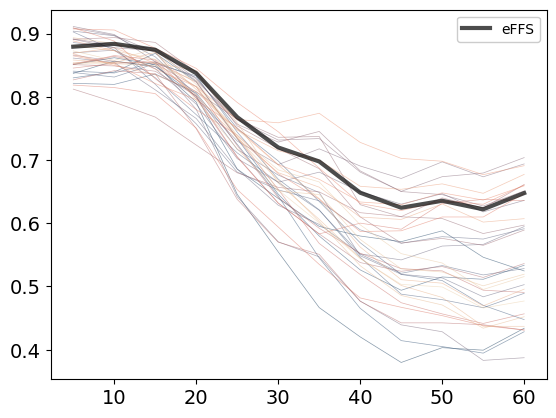

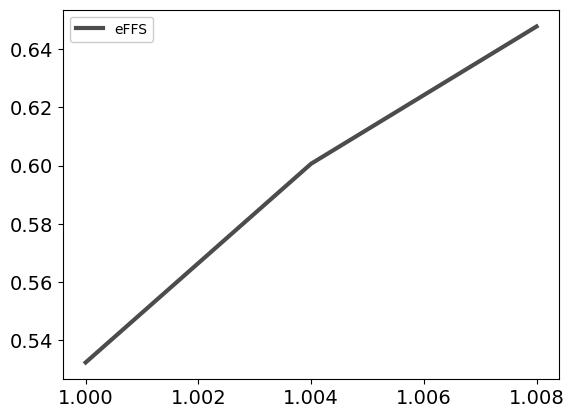

In [164]:
fig, ax = plt.subplots(1,1)

ax.set_prop_cycle('color', colors)

ax.plot(fcst_lead,ds.FSS[:,:,-1,0].T, alpha=0.5, lw=0.5);
ax.plot(fcst_lead,ds.EFSS[:,-1,0], color='k',lw=3, alpha=0.7, label='eFFS');
ax.legend()


fig, ax = plt.subplots(1,1)

ax.set_prop_cycle('color', colors)

ax.plot(ds.SCALES.values*1000/3000 + 1,ds.EFSS[-1,:,0], color='k',lw=3, alpha=0.7, label='eFFS');
ax.legend()

In [ ]:
exp = 'CI_10min'
ds = xr.open_dataset(glob.glob(os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, 'fss_compdz.nc'))[0])
threshold_level   = 30 # dbz
neighborhood_size = 24 # km 



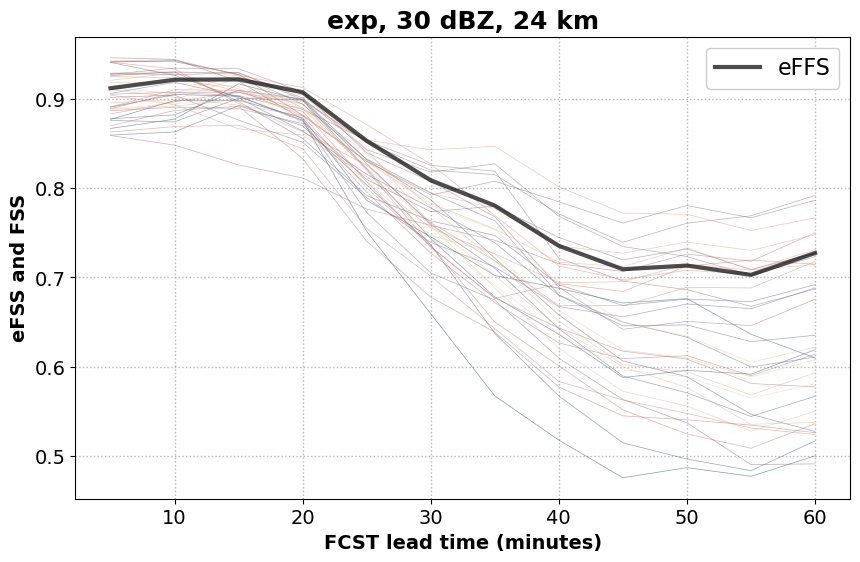

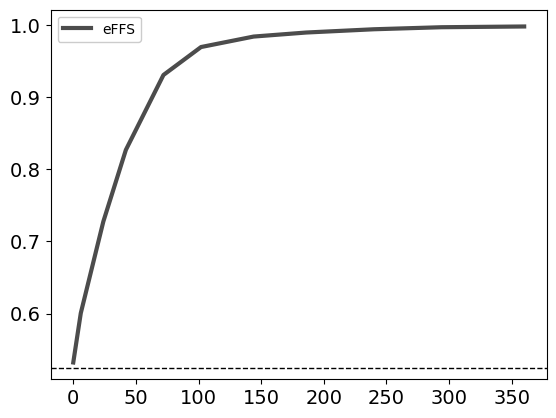

In [235]:
neighborhoods = ds.SCALES.values*1000


threshold_level   = 30 # dbz
neighborhood_size = 24 # km [  0.,   6.,  24.,  42.,  72., 102., 144., 186., 240., 294., 360.]
fcst_leadtime     = 60 # minutes

th_i = findnearest(ds.FCST_THLDS[0].values, threshold_level)
n_i  = findnearest(neighborhoods, neighborhood_size)
t_i  = findnearest(fcst_lead, fcst_leadtime)



fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.set_title(f'exp, {threshold_level} dBZ, {neighborhood_size} km', weight='bold')

ax.set_prop_cycle('color', colors)
ax.plot(fcst_lead,ds.FSS[:,:,n_i, th_i].T, alpha=0.5, lw=0.5);
ax.plot(fcst_lead,ds.EFSS[:,n_i, th_i], color='k',lw=3, alpha=0.7, label='eFFS');
ax.legend(fontsize=16)
ax.grid(ls=':', alpha=0.7)
ax.set_xlabel('FCST lead time (minutes)')
ax.set_ylabel('eFSS and FSS')




fig, ax = plt.subplots(1,1)

ax.set_prop_cycle('color', colors)
# ax.plot(ds.SCALES.values*1000,ds.EFSS[0,:,th_i], color='k',lw=3, alpha=0.7, label='eFFS');
# ax.plot(ds.SCALES.values*1000,ds.EFSS[6,:,th_i], color='k',lw=3, alpha=0.7, label='eFFS');
ax.plot(ds.SCALES.values*1000,ds.EFSS[t_i,:,th_i], color='k',lw=3, alpha=0.7, label='eFFS');

ax.axhline(ds.FSSU[t_i, th_i].values, color='k', ls='--', lw=1)
ax.legend()

In [248]:
threshold_level   = 50 # dbz [30., 35., 40., 45., 50., 55.]
neighborhood_size = 24 # km [  0.,   6.,  24.,  42.,  72., 102., 144., 186., 240., 294., 360.]
fcst_leadtime     = 60 # minutes

th_i = findnearest(ds.FCST_THLDS[0].values, threshold_level)
n_i  = findnearest(neighborhoods, neighborhood_size)
t_i  = findnearest(fcst_lead, fcst_leadtime)



# combining Priors, making Posteriors

RETURNING 2D FIELDS
[   0 2000 4000 6000]
RETURNING 2D FIELDS
[   0 2000 4000 6000]


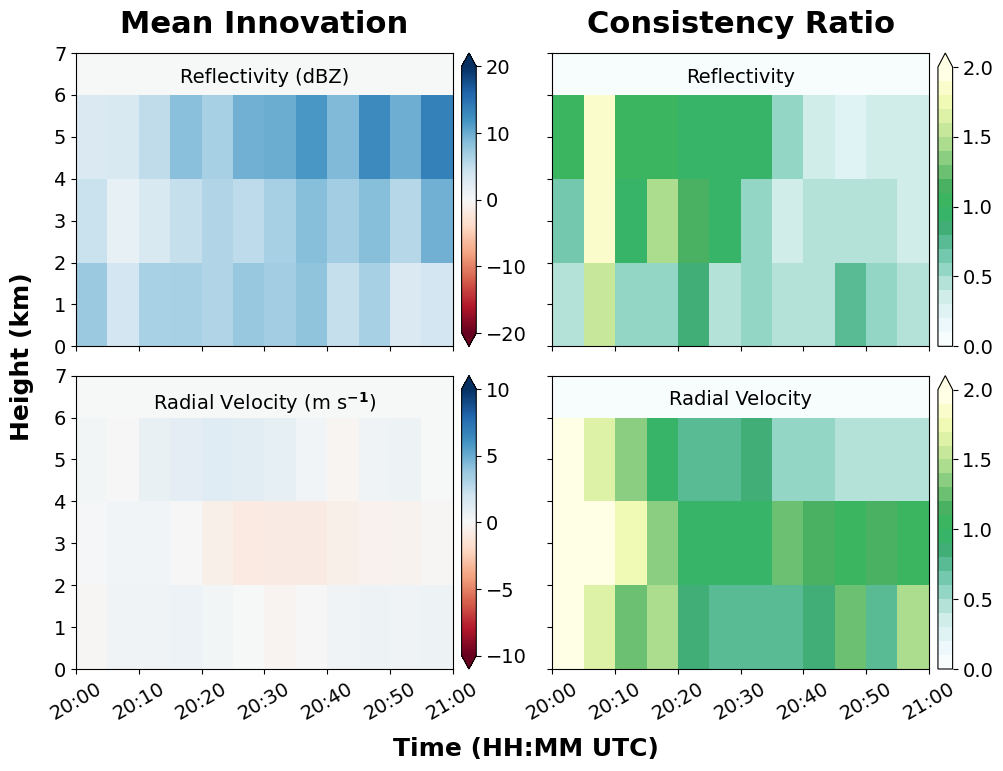

In [102]:
fig, axes = plt.subplots(2,2, figsize=(12,8), sharey=True, sharex=True)

vals = [20, 10]
fs = 14
cmap = CR_cmap()

for ii,var in enumerate(['REF', 'VR']): 
    TZ, CR, IN, SPRD, RMSI = get_stats_timeseries(experiment_location, only_pos_dbz=True, variable=var, full_field=True, dz=2000)
    t, z = list(TZ[0]), list(TZ[1]/1000)
    z.append(z[-1]+z[1]-z[0])
    t.append(t[-1]+(t[1]-t[0]))
    im1 = axes[ii,0].pcolormesh(t,z, IN, vmin=-1*vals[ii], vmax=vals[ii], cmap='RdBu')
    im2 = axes[ii,1].pcolormesh(t,z, CR, vmin=0, vmax=2, cmap=cmap)

    if ii ==1:format_time_ticks(axes[ii,0],t[:-1]);format_time_ticks(axes[ii,1],t[:-1])

    if ii==0: 
        axes[ii,0].text(0.5, .95, 'Reflectivity (dBZ)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Reflectivity',       ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    if ii==1: 
        axes[ii,0].text(0.5, .95, r'Radial Velocity (m s$\mathbf{^{-1}}$)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Radial Velocity',                        ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    plt.colorbar(im1, ax =axes[ii,0], pad=.02, extend='both')
    plt.colorbar(im2, ax =axes[ii,1], pad=.02, extend='max') 

axes[0,0].set_ylim(0,7)

plt.subplots_adjust(hspace=.1, wspace=0.05)

axes[0,0].set_title('Mean Innovation',   weight='bold',fontsize=22, y=1.04)
axes[0,1].set_title('Consistency Ratio', weight='bold',fontsize=22, y=1.04)

fig.text(0.5, 0.01, 'Time (HH:MM UTC)', ha='center', va='center', weight='bold', fontsize=18);
fig.text(0.07,0.5, 'Height (km)', weight='bold', va='center', fontsize=18, rotation='vertical');

In [144]:
13*9798

127374

In [10]:
##### SAVING PRIORS

# prior
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min'

file_version = 'Prior' 
dirname = os.path.join(exp,file_version+'*.nc')
file_list = sorted(glob.glob(dirname),key=os.path.getmtime)

num2obs = {11: ["VR"], 12:["DBZ"], 13:['DBZ0'], 14:['DBZ0_W']}
obs2num  = {'VR':11, 'DBZ':12, 'DBZ0':13, 'DBZ0_W':14}

with open(f'{exp}/{os.path.basename(exp)}.exp', 'rb') as f: exper = json.load(f)
obs = exper['DA_PARAMS']['obs_included']
obnum = [obs2num[ob] for ob in obs]

ensN = exper['ne']
t    = len(file_list)
n = np.max([len(xr.open_dataset(file).ob_num) for file in file_list])
times = [datetime.strptime(os.path.basename(file).replace(file_version, ''), '_%Y-%m-%d_%H:%M:%S.nc') for file in file_list]


# step one - make the skeleton of dataset
coords = { 't': np.arange(0, t),'ne': np.arange(0,ensN),'n':  np.arange(0, n)}
myds = xr.Dataset( coords)
#print(myds.keys())


# fill with nan variables of proper size
f = xr.open_dataset(file_list[0])
for v in list(f.keys()):
    if v not in ['type', 'dates']:
        if len(np.shape(f[v])) == 1:
            myds[v] = (('t', 'n'), np.zeros([t, n])*np.nan)
        if len(np.shape(f[v])) == 2:
            myds[v] = (('t', 'n', 'ne'), np.zeros([t, n, ensN])*np.nan)
f.close()
            
# fill nan variables with actual data
for fi, file in enumerate(file_list):
    f = xr.open_dataset(file)
    fn = len(f.ob_num)
    for v in list(myds.keys()):
        myds[v][fi, :fn] = f[v].values
    f.close()

# add time var
myds['time'] =  (('t'), times) 

# add masks for different variables

fix_kinds = myds.kind.values
fix_kinds[np.isnan(fix_kinds)] = -999
myds['kind'] = (('t', 'n'), fix_kinds)
for ob in obs:
    myds[ob] = (('t', 'n'), myds['kind'].values == obs2num[ob])


##### now add in the posterior values!!
myds['Hxf_post']= (('t', 'n', 'ne'), np.zeros([t, n, ensN])*np.nan)
myds['Hxfbar_post']= (('t', 'n'), np.zeros([t, n])*np.nan)
myds['outlier_post']= (('t', 'n'), np.zeros([t, n])*np.nan)

file_version='Posterior'
dirname = os.path.join(exp,file_version+'*.nc')
file_list = sorted(glob.glob(dirname),key=os.path.getmtime)
for fi, file in enumerate(file_list):
    f = xr.open_dataset(file)
    fn = len(f.ob_num)
    #for v in list(myds.keys()):
    myds['Hxf_post'][fi, :fn] = f['Hxf'].values
    myds['Hxfbar_post'][fi, :fn] = f['Hxfbar'].values
    myds['outlier_post'][fi, :fn] = f['outlier'].values
    f.close()

savename = os.path.join(os.path.dirname(file_list[0]), f'AllPrior_Post.nc')
myds.to_netcdf(savename, format='NETCDF4')

In [95]:
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_0'
ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
var = 'DBZ'

#dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)



In [318]:
dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
print(var, exp)

DBZ0_W /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w


/tmp/ipykernel_2027532/2346624567.py:35: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical


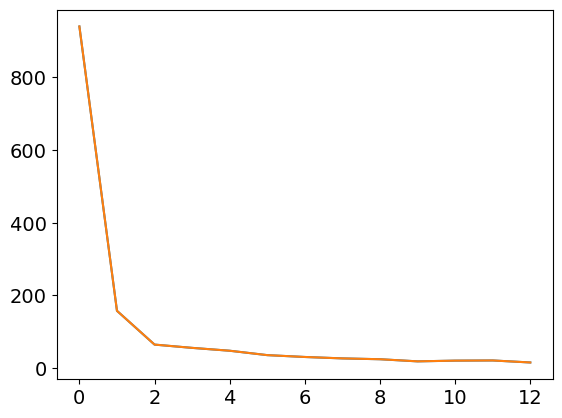

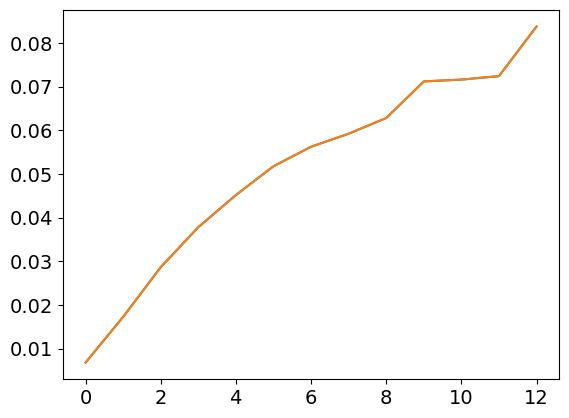

In [156]:
plt.figure()
plt.plot(crt)
plt.plot(CR)

plt.figure()
plt.plot(RMSI)
plt.plot(RMSI_n)

In [157]:
new_inno = [None]*(len(times)*2)
new_inno[::2] = inno
new_inno[1::2] = inno_post

new_time = [None]*(len(times)*2)
new_time[::2] =times
new_time[1::2] = times

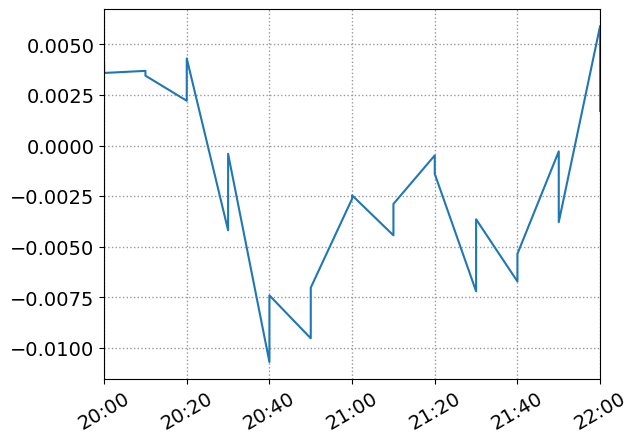

In [168]:
fig,ax = plt.subplots()
ax.plot(new_time, new_inno)
ax.grid()
format_time_ticks(ax,new_time, approx_number_of_ticks=6)

In [26]:


hxf_dbz = get_var(ds, 'Hxf', 'DBZ')
hxf_vr = get_var(ds, 'Hxf', 'VR')

hxf_dbz_post = get_var(ds, 'Hxf_post', 'DBZ')
hxf_vr_post = get_var(ds, 'Hxf_post', 'VR')

outliers = get_var(ds, 'outlier', 'DBZ')
hxf_dbz[outliers > 3] = np.nan

In [97]:
err = get_var(ds, 'error', 'DBZ')
err = err[np.isnan(err)==False]
np.unique(err)

array([49.])

array([49.])

In [24]:
np.shape(hxf_dbz)

hxf_dbz[outliers > 3] = np.nan

(13, 2426, 36)

In [25]:
np.shape(outliers)

(13, 2426)

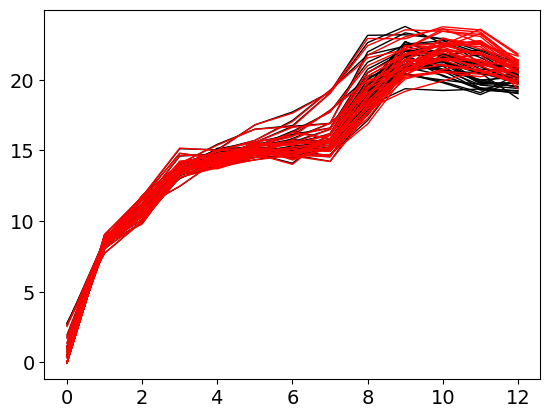

In [28]:

hxf_dbz = get_var(ds, 'Hxf', 'DBZ')
plt.plot(np.nanmean(hxf_dbz , axis=1), lw=1, color='k');

hxf_dbz[outliers > 3] = np.nan
plt.plot(np.nanmean(hxf_dbz , axis=1), lw=1, color='r');
#plt.plot(np.nanmean(hxf_dbz_post[outliers<=3] , axis=1), lw=1, color='r');

In [227]:
pos1[0]

Timestamp('2024-05-08 20:03:00')

In [266]:
def draw_plot(ax,data, pos,edge_color, fill_color):
  
    bp = ax.boxplot(data, positions= pos, widths=0.3, patch_artist=True, sym='d')
    for element in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(bp[element], color=edge_color)
    for patch in bp['boxes']:
        patch.set(facecolor=fill_color)
    plt.setp(bp['fliers'], markersize=3.0)
    plt.setp(bp['fliers'], alpha=0.5)

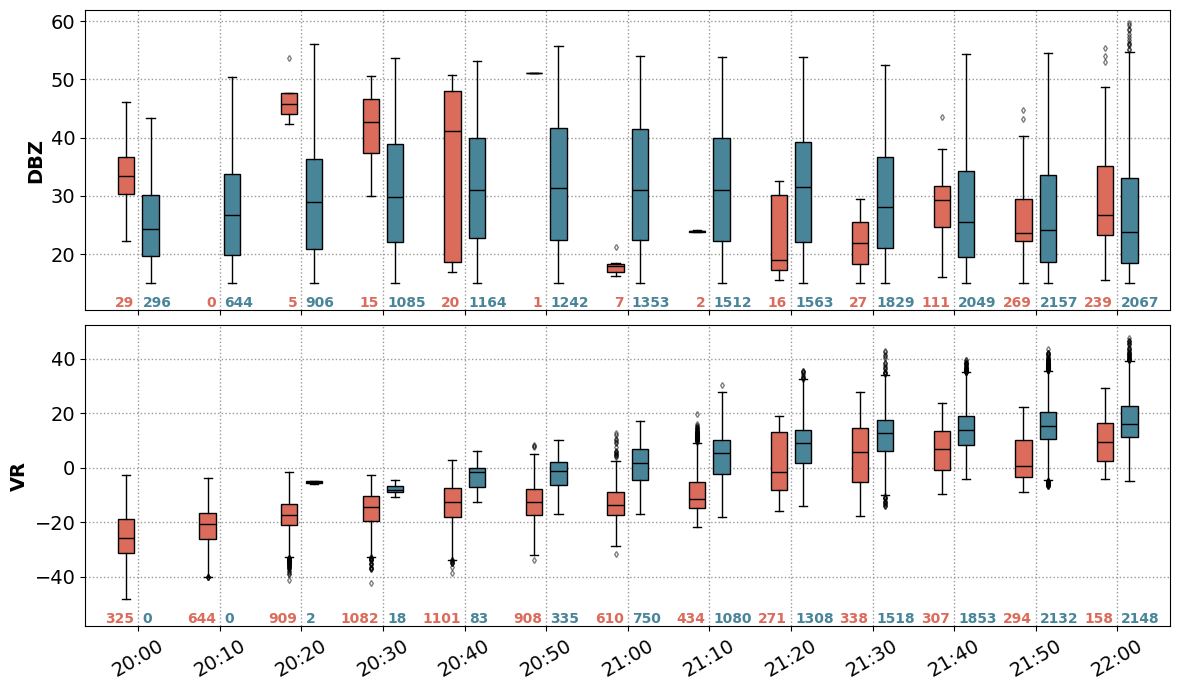

In [312]:
fig, axes = plt.subplots(2,1, figsize=(14, 8),sharex=True)

for ax, var in zip(axes, [ 'DBZ', 'VR']):

    keep_vals = []
    drop_vals = []
    
    for t in np.arange(13):
        sub = get_ds(ds, var, t)
     
        keep_vals.append(sub.value.values[sub.outlier <= 3])
        drop_vals.append(sub.value.values[sub.outlier > 3])
        
    num_keep = [len(v) for v in keep_vals]
    num_drop = [len(v) for v in drop_vals]

   

    offset=0.15
    pos1, pos2 = np.arange(len(keep_vals))+offset,np.arange(len(keep_vals))-offset
    
    draw_plot(ax,keep_vals, pos1,  'k', '#498599')
    draw_plot(ax, drop_vals, pos2, 'k', '#db6b5a')
    
    y1, y2 = (ax.get_ylim())
    yoff = (y2-y1)*.05
    ax.set_ylim(y1-yoff, y2)
    
    y1, y2 = (ax.get_ylim())
    yoff = (y2-y1)*.01
    y = y1+yoff
    for x in np.arange(len(keep_vals)):
        ax.text(x-.05,y, num_drop[x], ha='right',weight='bold', color='#db6b5a')
        ax.text(x+.05,y, num_keep[x], ha='left', weight='bold', color='#498599')
    
    ax.set_xticks(np.arange(len(keep_vals)), [t.strftime('%H:%M') for t in times], rotation=30);
    ax.grid()

    ax.set_ylabel(var)

plt.subplots_adjust(hspace=0.05)


In [9]:



# figure out dimensions for arrays
ensN = exper['ne']
t    = len(file_list)


In [ ]:
# step one, make the 

In [107]:

values    = np.zeros([t,n])*np.nan
outlier   = np.zeros([t,n])*np.nan
var_stdev = np.zeros([t,n])*np.nan



Hxf    = np.zeros([t,n,ensN])*np.nan


In [111]:
np.shape(outlierL[0])


(5966,)

In [64]:
np.shape(kindL[0, kindL[0] == 11])

TypeError: list indices must be integers or slices, not tuple

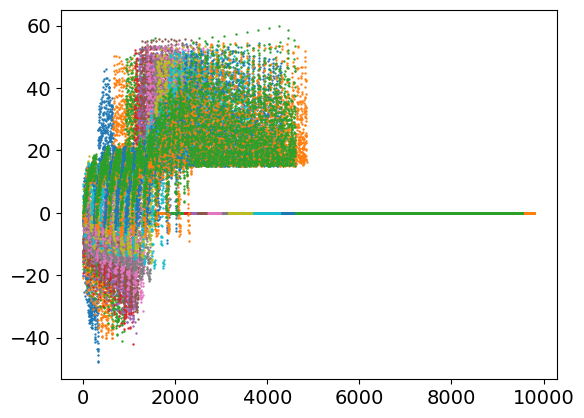

In [61]:
for i in range(allf):
    plt.scatter(range(len(values[i])), values[i], s=0.5)

In [42]:
values = np.zeros([len(file_list), size])*np.nan

In [47]:
for i in range(allf):
    valsize = len(valueL[i])
    values[i, :valsize] = valueL[i]

In [ ]:
size = np.max([np.shape(valueL[i]) for i in range(allf)])

In [45]:

size = np.max([np.shape(valueL[i]) for i in range(allf)])

In [26]:
dirname = os.path.join(exps[1],_prior_files)
#plotfilename='DBZ_CR'
#noshow=True

bin_delta=1

file_list = glob.glob(dirname)
file_list = sorted(file_list,key=os.path.getmtime)

full=[]
fop = []
variable='REF0'

    #full.append( value[index] - Hxf[index,:] ) #hxfbar is the mean model values

for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            #datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))


            index_kind  = getIndexVariable(kind,variable)

            temp = (dep[index_kind][:])# - Hxf[index_kind,:])
            temp2 = Hxf[index_kind,:]
            if n == 0:
                full = temp.copy()
                fop = temp2.copy()
            else:
                full = np.concat([full, temp], axis=0)
                fop = np.concat([fop, temp2], axis=0)
            

In [351]:
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w'
ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)

var='DBZ0_W'

full = (get_var(ds,'value', var)[:,:,np.newaxis]-get_var(ds,'Hxf', var)).flatten()
full = full[np.isnan(full)==False]

In [ ]:
for i in r

In [354]:
bins

array([-38.19175564, -38.09175564, -37.99175564, -37.89175564,
       -37.79175564, -37.69175564, -37.59175564, -37.49175564,
       -37.39175564, -37.29175564, -37.19175564, -37.09175564,
       -36.99175564, -36.89175564, -36.79175564, -36.69175564,
       -36.59175564, -36.49175564, -36.39175564, -36.29175564,
       -36.19175564, -36.09175564, -35.99175564, -35.89175564,
       -35.79175564, -35.69175564, -35.59175564, -35.49175564,
       -35.39175564, -35.29175564, -35.19175564, -35.09175564,
       -34.99175564, -34.89175564, -34.79175564, -34.69175564,
       -34.59175564, -34.49175564, -34.39175564, -34.29175564,
       -34.19175564, -34.09175564, -33.99175564, -33.89175564,
       -33.79175564, -33.69175564, -33.59175564, -33.49175564,
       -33.39175564, -33.29175564, -33.19175564, -33.09175564,
       -32.99175564, -32.89175564, -32.79175564, -32.69175564,
       -32.59175564, -32.49175564, -32.39175564, -32.29175564,
       -32.19175564, -32.09175564, -31.99175564, -31.89

[     1      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      1      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      1      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      1      0
      

(-5.0, 0.1)

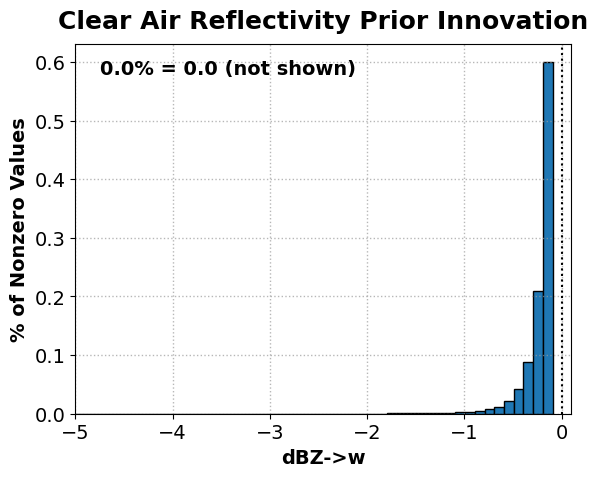

In [353]:
eqzero = 100*list(full.flatten()).count(0.0)/len(full.flatten())

width = .1
bins = np.arange(np.min(full), 0, width)
counts, bin_edges  = np.histogram(full.flatten(), bins=bins)
#ncounts, nbin_edges  = np.histogram(full.flatten(), bins=bins)

print(counts)

print(sum(counts))
#print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
#nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Clear Air Reflectivity Prior Innovation', weight='bold', y=1.02)
plt.bar(bin_c, counts/sum(counts), width=width, edgecolor='k')

plt.text(0.05, .96, f"{eqzero:.1f}% = 0.0 (not shown)",va='top', fontsize=14, weight='bold', transform=plt.gca().transAxes)

plt.xlabel('dBZ->w')
plt.ylabel('% of Nonzero Values')
plt.axvline(0, color='k', ls=':')
plt.grid(ls=":", alpha=0.7)

plt.xlim(-5, .1)

/tmp/ipykernel_1466515/2940125403.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))


Text(0.5, 0, 'Time (UTC)')

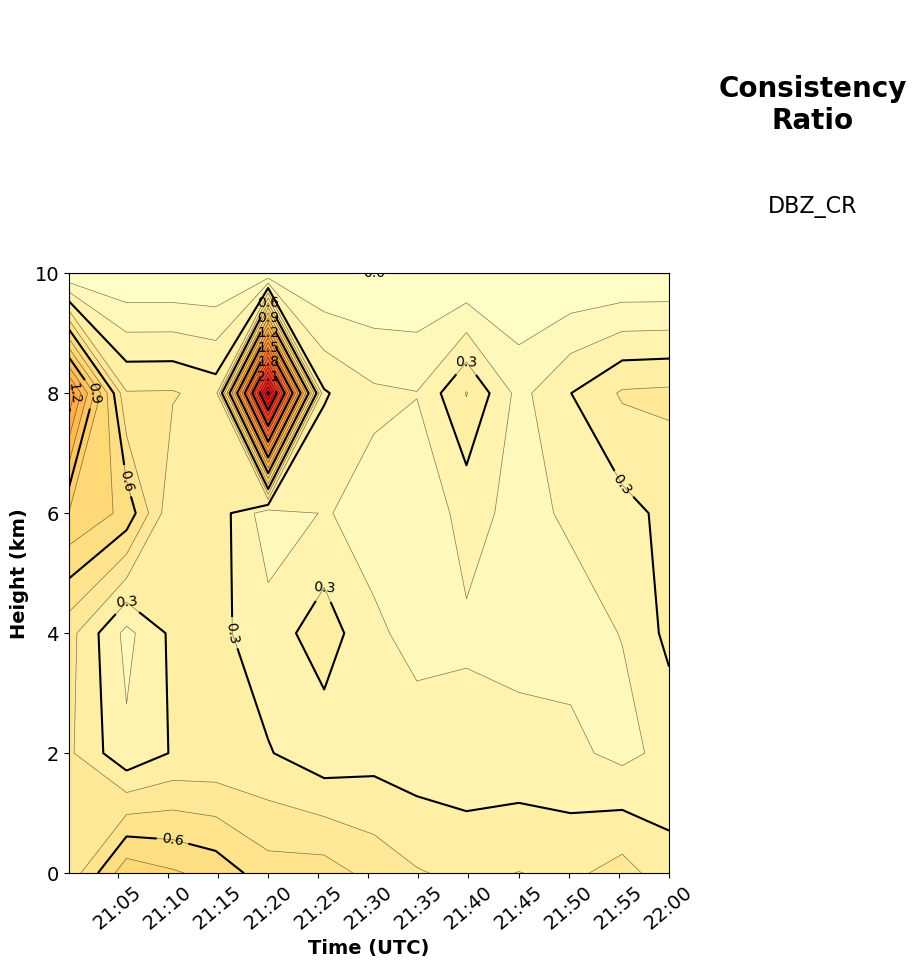

In [5]:
_cmin, _cmax = 0.0, 1.1   # limits for the single line plots...

variable = "VR"   # valid variables:  VR, DBZ
variable = 11   # valid variables:  VR, DBZ

sec_utime = "seconds since 1970-01-01 00:00:00"
auto_clevels = True

# definitions for the plot layout with multiple panels
left, width = 0.1, 0.5
bottom, height = 0.1, 0.5
bottom_h = left_h = left+width+0.03

rectC = [left, bottom, width, height]
rectX = [left, bottom_h, width, 0.2]
rectY = [left_h, bottom, 0.2, height]

fig = P.figure(figsize=(12,12))
fig.text(0.72, 0.72, "\n\nConsistency\nRatio", size=20, va="baseline", ha="center", multialignment="center", weight='bold')
fig.text(0.72, 0.65, plotfilename, size=16, va="baseline", ha="center", multialignment="center")


axC = P.axes(rectC)

zmin, zmax, cint = nice_mxmnintvl(zbins.min()/1000., zbins.max()/1000., outside=True, cint=1.0)
zmin = 0.0

if auto_clevels:
    cmin, cmax, cint, clevels = nice_clevels(0, 3, outside=False, cint = 0.1)
else:
    clevels = np.arange(spread_limits[0], spread_limits[1], spread_limits[2])

cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))
axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k', linewidths=0.5, alpha=0.5)
cs2=axC.contour(datebins,  zbins/1000., CR_TZ, cs1.levels[::3], colors='k')

start = datebins[0]
end   = datebins[-1]

nticks_approx = 8
minute_interval = 5*round((end-start).seconds/(nticks_approx*60*5)) #find the best interval divisble by 5 based on nticks

axC.set_xlim(start, end)
axC.set_ylim(zmin,zmax)

maj_loc = mdates.MinuteLocator(interval=minute_interval)
axC.xaxis.set_major_locator(maj_loc)
dateFmt = mdates.DateFormatter('%H:%M')
axC.xaxis.set_major_formatter(dateFmt)

labels = axC.get_xticklabels()
P.setp(labels, rotation=40, fontsize=14)

axC.clabel(cs2, inline=1, fontsize=10, fmt="%1.1f")
axC.set_ylabel("Height (km)", weight='bold')
axC.set_xlabel("Time (UTC)",weight='bold')

# ens stuff